In [ ]:
# ============================================================
# Gold 05 - Anomaly Detection Timeline Validation
# Utils-Aligned Bootstrap
# ============================================================

from __future__ import annotations

from pathlib import Path
from typing import Optional, Sequence, Any

import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.paths import get_paths
from utils.logging_setup import configure_logging, log_layer_paths
from utils.ledger import Ledger
from utils.file_io import load_data, save_data, save_json
from utils.pipeline_config_loader import load_pipeline_config
from utils.truths import (
    identify_meta_columns,
    identify_feature_columns,
    extract_truth_hash,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    make_process_run_id,
)

# optional existing helper module if you already saved it into utils or notebook path
try:
    from utils.cascade_row_tracking import get_stage_detected_rows_dataframe
except Exception:
    get_stage_detected_rows_dataframe = None


# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)


In [64]:
# ============================================================
# Configuration
# ============================================================

DATASET_NAME = "pump"
PIPELINE_STAGE = "gold_anomaly_detection"
PIPELINE_MODE = "train"
PIPELINE_PROFILE = "default"

SELECTED_RUN_KEY = "cascade_defaults"
# valid:
#   baseline
#   cascade_defaults
#   cascade_tuned
#   stage3_improved

USE_GLOBAL_RESULTS_IF_AVAILABLE = True

RECOVERY_STABILITY_ROWS = 30
RECOVERY_STARTS_AFTER_BROKEN = True

ROW_ID_COLUMN = "meta__row_id"
TIME_AXIS_CANDIDATES = ["time_index", "event_step", "event_time"]
STATUS_COLUMN_CANDIDATES = ["machine_status", "status", "state"]

DEFAULT_SENSOR_FOR_TIMELINE = "sensor_00"
PLOT_WINDOW_BEFORE_CENTER = 300
PLOT_WINDOW_AFTER_CENTER = 300
PLOT_ALERT_MARKER_SIZE = 18
ALERT_PACKET_MAX_GAP_ROWS = 5

PLOT_RUN_LABEL_MAP = {
    "baseline": "Baseline Isolation Forest",
    "cascade_defaults": "Cascade Defaults",
    "cascade_tuned": "Cascade Tuned",
    "stage3_improved": "Stage 3 Improved",
}

RUN_CONFIG_MAP = {
    "baseline": {
        "target_flag_column": "baseline_flag",
        "primary_score_column": "baseline_score",
        "primary_decision_column": "baseline_decision",
        "run_family": "baseline",
    },
    "cascade_defaults": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
    "cascade_tuned": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
    "stage3_improved": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
}

if SELECTED_RUN_KEY not in RUN_CONFIG_MAP:
    raise ValueError(
        f"Unsupported SELECTED_RUN_KEY: {SELECTED_RUN_KEY}. "
        f"Valid keys: {list(RUN_CONFIG_MAP)}"
    )

PLOT_RUN_LABEL = PLOT_RUN_LABEL_MAP.get(SELECTED_RUN_KEY, SELECTED_RUN_KEY)
SELECTED_RUN_CONFIG = RUN_CONFIG_MAP[SELECTED_RUN_KEY]

TARGET_FLAG_COLUMN = SELECTED_RUN_CONFIG["target_flag_column"]
PRIMARY_SCORE_COLUMN = SELECTED_RUN_CONFIG["primary_score_column"]
PRIMARY_DECISION_COLUMN = SELECTED_RUN_CONFIG["primary_decision_column"]
RUN_FAMILY = SELECTED_RUN_CONFIG["run_family"]

In [65]:
# ============================================================
# Paths, Config, Logger, Ledger
# ============================================================

PROCESS_RUN_ID = make_process_run_id(prefix="gold05_anomaly_detection")

paths = get_paths()

logger = configure_logging(
    name="capstone.gold.anomaly_detection",
    log_file=paths.logs / "gold_anomaly_detection.log",
    overwrite_handlers=False,
)

log_layer_paths(paths, current_layer="gold", logger=logger)

loaded_config = load_pipeline_config(
    config_root=paths.configs,
    stage=PIPELINE_STAGE,
    dataset=DATASET_NAME,
    mode=PIPELINE_MODE,
    profile=PIPELINE_PROFILE,
    project_root=paths.root,
)


CONFIG = loaded_config.data
RESOLVED_PATHS = CONFIG["resolved_paths"]
VERSIONS = CONFIG["versions"]

ledger = Ledger(
    stage="gold_anomaly_detection",
    recipe_id=PROCESS_RUN_ID,
)

ledger.add(
    kind="decision",
    step="notebook_init",
    message="Initialized Gold 05 anomaly detection notebook with utils-based paths/config/logging.",
    why="Gold 05 should align with the rest of the capstone project architecture.",
    consequence="Result loading, exports, logs, and truths will follow project-standard utilities.",
    data={
        "dataset_name": DATASET_NAME,
        "pipeline_stage": PIPELINE_STAGE,
        "pipeline_mode": PIPELINE_MODE,
        "process_run_id": PROCESS_RUN_ID,
        "selected_run_key": SELECTED_RUN_KEY,
    },
    logger=logger,
)

2026-04-21 14:35:46,221 | INFO | capstone.gold.anomaly_detection | Project Root Path Loaded: /workspace
2026-04-21 14:35:46,223 | INFO | capstone.gold.anomaly_detection | Project Logging Path Loaded: /workspace/logs
2026-04-21 14:35:46,224 | INFO | capstone.gold.anomaly_detection | Project Artifacts Path Loaded: /workspace/artifacts
2026-04-21 14:35:46,225 | INFO | capstone.gold.anomaly_detection | Project Notebooks Path Loaded: /workspace/notebooks
2026-04-21 14:35:46,228 | INFO | capstone.gold.anomaly_detection | Project Truths Path Loaded: /workspace/artifacts/truths
2026-04-21 14:35:46,230 | INFO | capstone.gold.anomaly_detection | Project Data Path Loaded: /workspace/data
2026-04-21 14:35:46,231 | INFO | capstone.gold.anomaly_detection | Previous Layer (Silver) Path Loaded: /workspace/data/silver
2026-04-21 14:35:46,232 | INFO | capstone.gold.anomaly_detection | Previous Layer (Silver) Training Path Loaded: /workspace/data/silver/train
2026-04-21 14:35:46,234 | INFO | capstone.gol

{'ts_utc': '2026-04-21T14:35:46.379201+00:00',
 'stage': 'gold_anomaly_detection',
 'recipe': 'gold05_anomaly_detection__20260421T143546Z',
 'kind': 'decision',
 'step': 'notebook_init',
 'message': 'Initialized Gold 05 anomaly detection notebook with utils-based paths/config/logging.',
 'why': 'Gold 05 should align with the rest of the capstone project architecture.',
 'consequence': 'Result loading, exports, logs, and truths will follow project-standard utilities.',
 'data': {'dataset_name': 'pump',
  'pipeline_stage': 'gold_anomaly_detection',
  'pipeline_mode': 'train',
  'process_run_id': 'gold05_anomaly_detection__20260421T143546Z',
  'selected_run_key': 'cascade_defaults'}}

In [66]:
# ============================================================
# Resolved Result Paths
# ============================================================

RUN_RESULT_PATH_MAP = {
    "baseline": RESOLVED_PATHS["baseline_results_path_pickle"],
    "cascade_defaults": RESOLVED_PATHS["cascade_defaults_results_path_pickle"],
    "cascade_tuned": RESOLVED_PATHS["cascade_tuned_results_path_pickle"],
    "stage3_improved": RESOLVED_PATHS["cascade_stage3_improved_results_path_pickle"],
}

ANOMALY_DETECTION_ARTIFACT_DIR = Path(RESOLVED_PATHS["gold_artifacts_dir"]) / "anomaly_detection"
ANOMALY_DETECTION_EXPORT_DIR = ANOMALY_DETECTION_ARTIFACT_DIR / "exports"
ANOMALY_DETECTION_PLOT_DIR = ANOMALY_DETECTION_ARTIFACT_DIR / "plots"

ANOMALY_DETECTION_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
ANOMALY_DETECTION_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
ANOMALY_DETECTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

GOLD05_LEDGER_PATH = ANOMALY_DETECTION_ARTIFACT_DIR / f"ledger__{DATASET_NAME}__gold_anomaly_detection.json"

logger.info("Selected run artifact path: %s", RUN_RESULT_PATH_MAP[SELECTED_RUN_KEY])

ledger.add(
    kind="decision",
    step="resolved_run_paths",
    message="Resolved selected run artifact path from pipeline config.",
    why="Gold 05 should load scored outputs from config-derived artifact paths by default.",
    consequence="Notebook can run standalone after kernel reset.",
    data={
        "selected_run_key": SELECTED_RUN_KEY,
        "selected_run_path": RUN_RESULT_PATH_MAP[SELECTED_RUN_KEY],
    },
    logger=logger,
)

2026-04-21 14:35:46,448 | INFO | capstone.gold.anomaly_detection | Selected run artifact path: /workspace/artifacts/gold/pump/pump__gold__cascade_defaults_results.pkl
2026-04-21 14:35:46,450 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:35:46.450722+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'decision', 'step': 'resolved_run_paths', 'message': 'Resolved selected run artifact path from pipeline config.', 'why': 'Gold 05 should load scored outputs from config-derived artifact paths by default.', 'consequence': 'Notebook can run standalone after kernel reset.', 'data': {'selected_run_key': 'cascade_defaults', 'selected_run_path': '/workspace/artifacts/gold/pump/pump__gold__cascade_defaults_results.pkl'}}


{'ts_utc': '2026-04-21T14:35:46.450722+00:00',
 'stage': 'gold_anomaly_detection',
 'recipe': 'gold05_anomaly_detection__20260421T143546Z',
 'kind': 'decision',
 'step': 'resolved_run_paths',
 'message': 'Resolved selected run artifact path from pipeline config.',
 'why': 'Gold 05 should load scored outputs from config-derived artifact paths by default.',
 'consequence': 'Notebook can run standalone after kernel reset.',
 'data': {'selected_run_key': 'cascade_defaults',
  'selected_run_path': '/workspace/artifacts/gold/pump/pump__gold__cascade_defaults_results.pkl'}}

In [ ]:
# ============================================================
# Selected Results Loader
# ============================================================

def load_selected_results_from_utils(
    *,
    selected_run_key: str,
    use_globals_if_available: bool = True,
) -> pd.DataFrame:
    """
    Load the selected scored dataframe using:
    1. globals fallback when explicitly allowed
    2. artifact path from config via utils.file_io / pickle

    This version uses globals().get(...) so Pylance does not complain
    about possibly undefined notebook variables.
    """
    if use_globals_if_available:
        primary_global_name_map = {
            "baseline": "baseline_results",
            "cascade_defaults": "cascade_results",
            "cascade_tuned": "cascade_tuned_results",
            "stage3_improved": "stage3_improved_results",
        }

        primary_global_name = primary_global_name_map.get(selected_run_key)
        primary_global_object = (
            globals().get(primary_global_name)
            if primary_global_name is not None
            else None
        )

        if isinstance(primary_global_object, pd.DataFrame):
            logger.info(
                "Using in-memory %s from globals.",
                primary_global_name,
            )
            return primary_global_object.copy()

        # Fallback for cascade notebooks that only left cascade_results in memory.
        if selected_run_key in {"cascade_defaults", "cascade_tuned", "stage3_improved"}:
            cascade_results_object = globals().get("cascade_results")

            if isinstance(cascade_results_object, pd.DataFrame):
                logger.info(
                    "Using in-memory cascade_results from globals as fallback for %s.",
                    selected_run_key,
                )
                return cascade_results_object.copy()

    result_path = Path(RUN_RESULT_PATH_MAP[selected_run_key])

    if not result_path.exists():
        raise FileNotFoundError(
            f"Selected run artifact path does not exist: {result_path}"
        )

    logger.info("Loading selected results from artifact path: %s", result_path)

    if result_path.suffix.lower() in {".pkl", ".pickle"}:
        dataframe = pd.read_pickle(result_path)
    else:
        dataframe = load_data(result_path)

    return dataframe.copy()


selected_results = load_selected_results_from_utils(
    selected_run_key=SELECTED_RUN_KEY,
    use_globals_if_available=USE_GLOBAL_RESULTS_IF_AVAILABLE,
)

ledger.add(
    kind="step",
    step="load_selected_results",
    message="Loaded selected scored dataframe for Gold 05 anomaly validation.",
    why="Timeline validation operates on a single scored run at a time.",
    consequence="All downstream summaries and plots will use the selected run output.",
    data={
        "selected_run_key": SELECTED_RUN_KEY,
        "row_count": int(len(selected_results)),
        "column_count": int(selected_results.shape[1]),
    },
    logger=logger,
)

display(selected_results.head(4))

2026-04-21 14:35:46,489 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/pump__gold__cascade_defaults_results.pkl


2026-04-21 14:35:48,303 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:35:48.303893+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'load_selected_results', 'message': 'Loaded selected scored dataframe for Gold 05 anomaly validation.', 'why': 'Timeline validation operates on a single scored run at a time.', 'consequence': 'All downstream summaries and plots will use the selected run output.', 'data': {'selected_run_key': 'cascade_defaults', 'row_count': 220320, 'column_count': 94}}


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,meta__row_id,meta__is_train_flag,stage1_score,stage1_decision,stage1_pred,stage1_flag,stage2_model_score,stage2_model_decision,stage2_model_pred,stage2_model_flag,stage2_score,stage2_raw_flag,stage2_flag,stage3_profile_breach_count,stage3_secondary_breach_count,stage3_persistence_flag,stage3_drift_flag,stage3_profile_breach_flag,stage3_corroboration_flag,stage3_rule_evidence_count,cascade_final_flag
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-04-21 02:36:14.502706+00:00,4d1e2a9d84b6d6ed635169533b5a51831376873b3446c1...,batch,14598431322315673869,run__001,sensor.csv,0,train,12447be32c212ae480ed363d899158bb2e2bf6bde750f6...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:00:00,NORMAL,0,True,-0.391431,0.108569,1,0,-0.425122,0.074878,1,0,NaN,0,0,0,1,0,0,0,1,1,0
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-04-21 02:36:14.502706+00:00,4d1e2a9d84b6d6ed635169533b5a51831376873b3446c1...,batch,15954729095895098000,run__001,sensor.csv,1,train,12447be32c212ae480ed363d899158bb2e2bf6bde750f6...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:01:00,NORMAL,1,True,-0.391431,0.108569,1,0,-0.425122,0.074878,1,0,NaN,0,0,0,1,0,0,0,1,1,0
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-04-21 02:36:14.502706+00:00,4d1e2a9d84b6d6ed635169533b5a51831376873b3446c1...,batch,10041703297090838359,run__001,sensor.csv,2,train,12447be32c212ae480ed363d899158bb2e2bf6bde750f6...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,-0.255821,-0.392159,0.537036,1.127271,0.670453,-0.485083,-0.468102,-0.185694,0.750017,-0.333349,-0.869635,0.742744,0.084552,-0.140848,0.063680,0.024252,-0.023257,-0.051481,0.031807,0.039803,0.034031,0.045869,0.539582,0.559032,0.045512,0.031031,-0.029962,-0.769896,-0.025671,0.380643,-0.866485,-0.748481,-0.586075,-0.053782,-0.147948,-0.214093,0.276319,-1.031250,-0.954545,0.454546,-0.999999,-0.882353,-0.166667,-0.045454,3.954546,0.964285,-0.608696,0.688715,1.833334,0.072992,2018-04-01 00:02:00,NORMAL,2,True,-0.384923,0.115077,1,0,-0.416018,0.083982,1,0,NaN,0,0,0,0,0,0,0,0,0,0
3,asset__001,pump,0,pump:asset__001:run__001:3,2026-04-21 02:36:14.502706+00:00,4d1e2a9d84b6d6ed6351

In [68]:
# ============================================================
# Timeline Helper Functions
# ============================================================

def resolve_first_present_column(
    dataframe: pd.DataFrame,
    candidates: Sequence[str],
    required: bool = True,
    label: str = "column",
) -> Optional[str]:
    for column in candidates:
        if column in dataframe.columns:
            return column

    if required:
        raise ValueError(
            f"Could not resolve required {label}. "
            f"Candidates checked: {list(candidates)}"
        )
    return None


def ensure_row_id_and_plot_order(
    dataframe: pd.DataFrame,
    row_id_column: str = ROW_ID_COLUMN,
    time_axis_column: Optional[str] = None,
) -> pd.DataFrame:
    out = dataframe.copy()

    if row_id_column not in out.columns:
        out[row_id_column] = np.arange(len(out), dtype=np.int64)

    if out[row_id_column].isna().any():
        raise ValueError(f"{row_id_column} contains null values.")

    if not out[row_id_column].is_unique:
        raise ValueError(f"{row_id_column} must be unique.")

    if time_axis_column is not None and time_axis_column in out.columns:
        out = out.sort_values(by=[time_axis_column, row_id_column]).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    out["plot_order_index"] = np.arange(len(out), dtype=np.int64)
    return out


def add_broken_anchor_columns(
    dataframe: pd.DataFrame,
    status_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    out["is_broken_row"] = (
        out[status_column].astype(str).str.upper().eq("BROKEN").astype(int)
    )

    broken_indices = out.index[out["is_broken_row"] == 1].tolist()
    if not broken_indices:
        raise ValueError("No BROKEN row found in scored dataframe.")

    first_broken_dataframe_index = broken_indices[0]
    first_broken_plot_order_index = int(out.loc[first_broken_dataframe_index, "plot_order_index"])

    out["first_broken_plot_order_index"] = first_broken_plot_order_index
    out["rows_to_first_broken"] = (
        first_broken_plot_order_index - out["plot_order_index"]
    ).astype(int)

    return out


def add_alert_and_normal_like_columns(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    if target_flag_column not in out.columns:
        raise ValueError(f"Missing required target flag column: {target_flag_column}")

    out["selected_final_alert_flag"] = out[target_flag_column].fillna(0).astype(int)
    out["is_normal_like_row"] = (out["selected_final_alert_flag"] == 0).astype(int)

    return out


def compute_forward_stable_normal_run(
    dataframe: pd.DataFrame,
    normal_like_column: str = "is_normal_like_row",
) -> pd.DataFrame:
    out = dataframe.copy()

    values = out[normal_like_column].fillna(0).astype(int).to_numpy()
    forward_run = np.zeros(len(values), dtype=np.int64)

    current_run = 0
    for idx in range(len(values) - 1, -1, -1):
        if values[idx] == 1:
            current_run += 1
        else:
            current_run = 0
        forward_run[idx] = current_run

    out["forward_normal_like_run_length"] = forward_run
    return out


def resolve_recovery_boundaries(
    dataframe: pd.DataFrame,
    stability_rows: int = RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken: bool = RECOVERY_STARTS_AFTER_BROKEN,
) -> dict[str, Any]:
    out = dataframe.copy()

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    recovery_start_plot_order_index = (
        first_broken_plot_order_index + 1
        if recovery_starts_after_broken
        else first_broken_plot_order_index
    )

    candidate_mask = (
        (out["plot_order_index"] >= recovery_start_plot_order_index)
        & (out["forward_normal_like_run_length"] >= stability_rows)
    )

    candidate_rows = out.loc[candidate_mask].copy()

    if candidate_rows.empty:
        recovery_end_plot_order_index = None
    else:
        recovery_end_plot_order_index = int(candidate_rows["plot_order_index"].iloc[0])

    return {
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_start_plot_order_index": recovery_start_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "recovery_stability_rows": int(stability_rows),
    }


def add_episode_phase_columns(
    dataframe: pd.DataFrame,
    recovery_boundary_payload: dict[str, Any],
) -> pd.DataFrame:
    out = dataframe.copy()

    first_broken = recovery_boundary_payload["first_broken_plot_order_index"]
    recovery_start = recovery_boundary_payload["recovery_start_plot_order_index"]
    recovery_end = recovery_boundary_payload["recovery_end_plot_order_index"]

    phase_values: list[str] = []

    for plot_idx in out["plot_order_index"].tolist():
        if plot_idx < first_broken:
            phase_values.append("pre_failure")
        elif plot_idx == first_broken:
            phase_values.append("failure")
        elif recovery_end is None:
            if plot_idx >= recovery_start:
                phase_values.append("recovery")
            else:
                phase_values.append("pre_failure")
        elif recovery_start <= plot_idx < recovery_end:
            phase_values.append("recovery")
        elif plot_idx >= recovery_end:
            phase_values.append("stable_normal")
        else:
            phase_values.append("pre_failure")

    out["episode_phase"] = phase_values
    out["is_recovery_row"] = (out["episode_phase"] == "recovery").astype(int)
    out["is_stable_normal_row"] = (out["episode_phase"] == "stable_normal").astype(int)

    return out


def classify_detection_rows(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    detection_classes: list[str] = []

    for _, row in out.iterrows():
        is_alert = int(row.get(target_flag_column, 0) or 0)

        if is_alert != 1:
            detection_classes.append("no_alert")
            continue

        phase = row.get("episode_phase", None)

        if phase == "pre_failure":
            detection_classes.append("early_warning")
        elif phase == "failure":
            detection_classes.append("failure_hit")
        elif phase == "recovery":
            detection_classes.append("recovery_alert")
        elif phase == "stable_normal":
            detection_classes.append("false_positive")
        else:
            detection_classes.append("unclassified_alert")

    out["detection_class"] = detection_classes
    return out

In [69]:
# ============================================================
# Build Timeline DataFrame
# ============================================================

time_axis_column = resolve_first_present_column(
    selected_results,
    TIME_AXIS_CANDIDATES,
    required=False,
    label="time axis column",
)

status_column = resolve_first_present_column(
    selected_results,
    STATUS_COLUMN_CANDIDATES,
    required=True,
    label="status column",
)

timeline_source_df = ensure_row_id_and_plot_order(
    selected_results,
    row_id_column=ROW_ID_COLUMN,
    time_axis_column=time_axis_column,
)

timeline_source_df = add_broken_anchor_columns(
    timeline_source_df,
    status_column=status_column,
)

timeline_source_df = add_alert_and_normal_like_columns(
    timeline_source_df,
    target_flag_column=TARGET_FLAG_COLUMN,
)

timeline_source_df = compute_forward_stable_normal_run(
    timeline_source_df,
    normal_like_column="is_normal_like_row",
)

recovery_boundary_payload = resolve_recovery_boundaries(
    timeline_source_df,
    stability_rows=RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
)

timeline_source_df = add_episode_phase_columns(
    timeline_source_df,
    recovery_boundary_payload=recovery_boundary_payload,
)

timeline_source_df = classify_detection_rows(
    timeline_source_df,
    target_flag_column=TARGET_FLAG_COLUMN,
)


In [70]:
def build_anomaly_timeline_dataframe(
    selected_results: pd.DataFrame,
    target_flag_column: str,
    status_column: str,
    row_id_column: str,
    time_axis_column: Optional[str],
    recovery_stability_rows: int,
    recovery_starts_after_broken: bool,
):
    df = ensure_row_id_and_plot_order(
        selected_results,
        row_id_column=row_id_column,
        time_axis_column=time_axis_column,
    )

    df = add_broken_anchor_columns(df, status_column=status_column)

    df = add_alert_and_normal_like_columns(
        df,
        target_flag_column=target_flag_column,
    )

    df = compute_forward_stable_normal_run(
        df,
        normal_like_column="is_normal_like_row",
    )

    recovery_boundary_payload = resolve_recovery_boundaries(
        df,
        stability_rows=recovery_stability_rows,
        recovery_starts_after_broken=recovery_starts_after_broken,
    )

    df = add_episode_phase_columns(
        df,
        recovery_boundary_payload=recovery_boundary_payload,
    )

    df = classify_detection_rows(
        df,
        target_flag_column=target_flag_column,
    )

    return df, recovery_boundary_payload

In [71]:
anomaly_timeline_dataframe, recovery_boundary_payload = build_anomaly_timeline_dataframe(
    selected_results,
    target_flag_column=TARGET_FLAG_COLUMN,
    status_column=status_column,
    row_id_column=ROW_ID_COLUMN,
    time_axis_column=time_axis_column,
    recovery_stability_rows=RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
)

ledger.add(
    kind="step",
    step="build_timeline_dataframe",
    message="Built anomaly timeline dataframe with failure/recovery phase annotations.",
    why="Gold 05 needs one canonical row-level validation frame.",
    consequence="All summaries, plots, and exports will derive from this dataframe.",
    data={
        "time_axis_column": time_axis_column,
        "status_column": status_column,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "recovery_boundary_payload": recovery_boundary_payload,
        "row_count": int(len(anomaly_timeline_dataframe)),
        "column_count": int(anomaly_timeline_dataframe.shape[1]),
    },
    logger=logger,
)

preview_columns = [
    "plot_order_index",
    status_column,
    "is_broken_row",
    TARGET_FLAG_COLUMN,
    "selected_final_alert_flag",
    "is_normal_like_row",
    "forward_normal_like_run_length",
    "episode_phase",
    "detection_class",
]
preview_columns = [c for c in preview_columns if c in anomaly_timeline_dataframe.columns]

display(anomaly_timeline_dataframe[preview_columns].head(40))

2026-04-21 14:36:55,236 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:36:55.236576+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'build_timeline_dataframe', 'message': 'Built anomaly timeline dataframe with failure/recovery phase annotations.', 'why': 'Gold 05 needs one canonical row-level validation frame.', 'consequence': 'All summaries, plots, and exports will derive from this dataframe.', 'data': {'time_axis_column': 'time_index', 'status_column': 'machine_status', 'target_flag_column': 'cascade_final_flag', 'recovery_boundary_payload': {'first_broken_plot_order_index': 17155, 'recovery_start_plot_order_index': 17156, 'recovery_end_plot_order_index': 18336, 'recovery_stability_rows': 30}, 'row_count': 220320, 'column_count': 105}}


,plot_order_index,machine_status,is_broken_row,cascade_final_flag,selected_final_alert_flag,is_normal_like_row,forward_normal_like_run_length,episode_phase,detection_class
0,0,NORMAL,0,0,0,1,17154,pre_failure,no_alert
1,1,NORMAL,0,0,0,1,17153,pre_failure,no_alert
2,2,NORMAL,0,0,0,1,17152,pre_failure,no_alert
3,3,NORMAL,0,0,0,1,17151,pre_failure,no_alert
4,4,NORMAL,0,0,0,1,17150,pre_failure,no_alert
5,5,NORMAL,0,0,0,1,17149,pre_failure,no_alert
6,6,NORMAL,0,0,0,1,17148,pre_failure,no_alert
7,7,NORMAL,0,0,0,1,17147,pre_failure,no_alert
8,8,NORMAL,0,0,0,1,17146,pre_failure,no_alert
9,9,NORMAL,0,0,0,1,17145,pre_failure,no_alert


In [72]:
# ============================================================
# Detected Row Review Helpers
# ============================================================

def build_detected_rows_review_dataframe(
    dataframe: pd.DataFrame,
    target_flag_column: str,
    score_column: Optional[str] = None,
    decision_column: Optional[str] = None,
    include_columns: Optional[Sequence[str]] = None,
    sort_by: str = "plot_order_index",
) -> pd.DataFrame:
    """
    Build a filtered detected-row review dataframe for the selected run.
    """
    out = dataframe.copy()

    candidate_columns = [
        ROW_ID_COLUMN,
        "plot_order_index",
        "meta__record_id",
        "time_index",
        "event_step",
        "event_time",
        "machine_status",
        "episode_phase",
        "detection_class",
        target_flag_column,
    ]

    if score_column is not None and score_column in out.columns:
        candidate_columns.append(score_column)

    if decision_column is not None and decision_column in out.columns:
        candidate_columns.append(decision_column)

    if include_columns is not None:
        for column in include_columns:
            if column in out.columns and column not in candidate_columns:
                candidate_columns.append(column)

    candidate_columns = [c for c in candidate_columns if c in out.columns]

    detected_rows_df = out.loc[
        out[target_flag_column].fillna(0).astype(int) == 1,
        candidate_columns,
    ].copy()

    if sort_by in detected_rows_df.columns:
        detected_rows_df = detected_rows_df.sort_values(by=sort_by).reset_index(drop=True)

    return detected_rows_df


detected_rows_review_df = build_detected_rows_review_dataframe(
    anomaly_timeline_dataframe,
    target_flag_column=TARGET_FLAG_COLUMN,
    score_column=PRIMARY_SCORE_COLUMN if PRIMARY_SCORE_COLUMN in anomaly_timeline_dataframe.columns else None,
    decision_column=PRIMARY_DECISION_COLUMN if PRIMARY_DECISION_COLUMN in anomaly_timeline_dataframe.columns else None,
    include_columns=[
        "selected_final_alert_flag",
        "forward_normal_like_run_length",
        "is_broken_row",
    ],
)

ledger.add(
    kind="step",
    step="detected_rows_review",
    message="Built detected-row review dataframe for selected run.",
    why="Gold 05 should provide row-level review of all alert rows.",
    consequence="Detected rows can now be exported, inspected, and compared across runs.",
    data={"detected_row_count": int(len(detected_rows_review_df))},
    logger=logger,
)

display(detected_rows_review_df.head(30))

2026-04-21 14:36:55,519 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:36:55.519901+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'detected_rows_review', 'message': 'Built detected-row review dataframe for selected run.', 'why': 'Gold 05 should provide row-level review of all alert rows.', 'consequence': 'Detected rows can now be exported, inspected, and compared across runs.', 'data': {'detected_row_count': 19884}}


,meta__row_id,plot_order_index,meta__record_id,time_index,event_step,event_time,machine_status,episode_phase,detection_class,cascade_final_flag,stage2_score,stage2_model_decision,selected_final_alert_flag,forward_normal_like_run_length,is_broken_row
0,17154,17154,11031252919804255274,17154,17154,2018-04-12 21:54:00+00:00,NORMAL,pre_failure,early_warning,1,0.611132,-0.111132,1,0,0
1,17155,17155,7306247312672969352,17155,17155,2018-04-12 21:55:00+00:00,BROKEN,failure,failure_hit,1,0.591552,-0.091552,1,0,1
2,17156,17156,16171677129378469200,17156,17156,2018-04-12 21:56:00+00:00,RECOVERING,recovery,recovery_alert,1,0.579565,-0.079565,1,0,0
3,17157,17157,14211091896624741348,17157,17157,2018-04-12 21:57:00+00:00,RECOVERING,recovery,recovery_alert,1,0.585565,-0.085565,1,0,0
4,17158,17158,313266691668351730,17158,17158,2018-04-12 21:58:00+00:00,RECOVERING,recovery,recovery_alert,1,0.582486,-0.082486,1,0,0
5,17159,17159,5086261863442700928,17159,17159,2018-04-12 21:59:00+00:00,RECOVERING,recovery,recovery_alert,1,0.588661,-0.088661,1,0,0
6,17160,17160,11141286012755120792,17160,17160,2018-04-12 22:00:00+00:00,RECOVERING,recovery,recovery_alert,1,0.570978,-0.070978,1,0,0
7,17161,17161,12435410761567819601,17161,17161,2018-04-12 22:01:00+00:00,RECOVERING,recovery,recovery_alert,1,0.570978,-0.070978,1,0,0
8,17162,17162,16834369260743897814,17162,17162,2018-04-12 22:02:00+00:00,RECOVERING,recovery,recovery_alert,1,0.580877,-0.080877,1,0,0
9,17163,17163,13012502951683690117,17163,17163,2018-04-12 22:03:00+00:00,RECOVERING,recovery,recovery_alert,1,0.603127,-0.103127,1,0,0


In [73]:
def get_first_alert_index(df, col):
    if col not in df.columns:
        return None
    rows = df.loc[df[col].fillna(0).astype(int) == 1, "plot_order_index"]
    return int(rows.iloc[0]) if not rows.empty else None


stage_alerts = {
    "stage1_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage1_flag"),
    "stage2_raw_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage2_raw_flag"),
    "stage2_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage2_flag"),
    "cascade_final_flag": get_first_alert_index(anomaly_timeline_dataframe, "cascade_final_flag"),
    "baseline_flag": get_first_alert_index(anomaly_timeline_dataframe, "baseline_flag"),
    "first_broken": int(anomaly_timeline_dataframe["first_broken_plot_order_index"].iloc[0]),
}

stage_alerts

{'stage1_flag': 10421,
 'stage2_raw_flag': 10421,
 'stage2_flag': 17154,
 'cascade_final_flag': 17154,
 'baseline_flag': None,
 'first_broken': 17155}

- Stage 1 shows that it is alerting very early, about 6900 minutes prior. 
- Stage 2 is alerting 1 minute prior to fault. 

- This means our issue is with stage 2. 

In [74]:
stage1_detected_rows_df = build_detected_rows_review_dataframe(
    anomaly_timeline_dataframe,
    target_flag_column="stage1_flag",
    score_column="stage1_score" if "stage1_score" in anomaly_timeline_dataframe.columns else None,
    decision_column="stage1_decision" if "stage1_decision" in anomaly_timeline_dataframe.columns else None,
    include_columns=[
        "machine_status",
        "episode_phase",
        "detection_class",
        "stage2_raw_flag",
        "stage2_flag",
        "cascade_final_flag",
    ],
)

display(stage1_detected_rows_df.head(150))

,meta__row_id,plot_order_index,meta__record_id,time_index,event_step,event_time,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage1_decision,stage2_raw_flag,stage2_flag,cascade_final_flag
0,10421,10421,13040787562538299660,10421,10421,2018-04-08 05:41:00+00:00,NORMAL,pre_failure,no_alert,1,-0.501091,-0.001091,1,0,0
1,10422,10422,17181546761143259301,10422,10422,2018-04-08 05:42:00+00:00,NORMAL,pre_failure,no_alert,1,-0.508270,-0.008270,1,0,0
2,10424,10424,10863625578907073953,10424,10424,2018-04-08 05:44:00+00:00,NORMAL,pre_failure,no_alert,1,-0.509427,-0.009427,1,0,0
3,10425,10425,9940223489881459585,10425,10425,2018-04-08 05:45:00+00:00,NORMAL,pre_failure,no_alert,1,-0.504244,-0.004244,1,0,0
4,10426,10426,2673701136861205737,10426,10426,2018-04-08 05:46:00+00:00,NORMAL,pre_failure,no_alert,1,-0.503254,-0.003254,1,0,0
5,10427,10427,10298021739733576732,10427,10427,2018-04-08 05:47:00+00:00,NORMAL,pre_failure,no_alert,1,-0.501720,-0.001720,1,0,0
6,10428,10428,13817220964081962874,10428,10428,2018-04-08 05:48:00+00:00,NORMAL,pre_failure,no_alert,1,-0.510048,-0.010048,1,0,0
7,10429,10429,17431902560253693386,10429,10429,2018-04-08 05:49:00+00:00,NORMAL,pre_failure,no_alert,1,-0.500433,-0.000433,1,0,0
8,10432,10432,7556830595156906918,10432,10432,2018-04-08 05:52:00+00:00,NORMAL,pre_failure,no_alert,1,-0.504630,-0.004630,1,0,0
9,10433,10433,19320186527523733,10433,10433,2018-04-08 05:53:00+00:00,NORMAL,pre_failure,no_alert,1,-0.501502,-0.001502,1,0,0


#### Validate plot_order_index

In [ ]:
# =========================================================
# Validate plot_order_index on the selected timeline dataframe
# =========================================================
# Gold 05 should use anomaly_timeline_dataframe, not cascade_results.
# anomaly_timeline_dataframe is already created from selected_results and
# already receives plot_order_index from ensure_row_id_and_plot_order().

if "plot_order_index" not in anomaly_timeline_dataframe.columns:
    raise ValueError(
        "anomaly_timeline_dataframe is missing plot_order_index. "
        "Rerun the timeline build cells above."
    )

anomaly_timeline_dataframe["plot_order_index"] = (
    pd.to_numeric(
        anomaly_timeline_dataframe["plot_order_index"],
        errors="raise",
    )
    .astype(int)
)

print("plot_order_index ready on anomaly_timeline_dataframe.")
print(
    {
        "selected_run_key": SELECTED_RUN_KEY,
        "min": int(anomaly_timeline_dataframe["plot_order_index"].min()),
        "max": int(anomaly_timeline_dataframe["plot_order_index"].max()),
        "rows": int(len(anomaly_timeline_dataframe)),
    }
)

#### Validation Selected Run Window

In [ ]:
# =========================================================
# Selected-run debug window
# =========================================================
# Use anomaly_timeline_dataframe instead of cascade_results so this works
# for baseline, cascade defaults, cascade tuned, and stage3 improved runs.

debug_columns = [
    "plot_order_index",
    "time_index",
    "meta__row_id",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    TARGET_FLAG_COLUMN,
]

available_debug_columns = [
    column_name
    for column_name in debug_columns
    if column_name in anomaly_timeline_dataframe.columns
]

display(
    anomaly_timeline_dataframe.loc[
        anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
        available_debug_columns,
    ]
)

#### Stage 1 Early Window Review

In [ ]:
# =========================================================
# Stage 1 / early-window review
# =========================================================
# Build the column list first, then select. Do not put None inside .loc[].

stage1_early_window_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    "baseline_flag",
    "baseline_score",
    TARGET_FLAG_COLUMN,
]

stage1_early_window_columns = [
    column_name
    for column_name in stage1_early_window_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage1_early_window_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
    stage1_early_window_columns,
].copy()

display(stage1_early_window_df)

,plot_order_index,machine_status,episode_phase,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag
10380,10380,NORMAL,pre_failure,0,-0.408486,NaN,0,0,0
10381,10381,NORMAL,pre_failure,0,-0.408486,NaN,0,0,0
10382,10382,NORMAL,pre_failure,0,-0.416248,NaN,0,0,0
10383,10383,NORMAL,pre_failure,0,-0.414000,NaN,0,0,0
10384,10384,NORMAL,pre_failure,0,-0.408617,NaN,0,0,0
10385,10385,NORMAL,pre_failure,0,-0.415372,NaN,0,0,0
10386,10386,NORMAL,pre_failure,0,-0.415352,NaN,0,0,0
10387,10387,NORMAL,pre_failure,0,-0.422347,NaN,0,0,0
10388,10388,NORMAL,pre_failure,0,-0.429695,NaN,0,0,0
10389,10389,NORMAL,pre_failure,0,-0.420991,NaN,0,0,0


#### Stage 2 Pre-Failure Review Window

In [ ]:
# =========================================================
# Pre-failure review window
# =========================================================

stage2_pre_failure_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    TARGET_FLAG_COLUMN,
]

stage2_pre_failure_columns = [
    column_name
    for column_name in stage2_pre_failure_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage2_pre_failure_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(17000, 17155),
    stage2_pre_failure_columns,
].copy()

display(stage2_pre_failure_df.tail(100))

,plot_order_index,stage1_flag,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,machine_status,episode_phase
17056,17056,0,NaN,0,0,0,NORMAL,pre_failure
17057,17057,0,NaN,0,0,0,NORMAL,pre_failure
17058,17058,0,NaN,0,0,0,NORMAL,pre_failure
17059,17059,0,NaN,0,0,0,NORMAL,pre_failure
17060,17060,0,NaN,0,0,0,NORMAL,pre_failure
17061,17061,0,NaN,0,0,0,NORMAL,pre_failure
17062,17062,0,NaN,0,0,0,NORMAL,pre_failure
17063,17063,0,NaN,0,0,0,NORMAL,pre_failure
17064,17064,0,NaN,0,0,0,NORMAL,pre_failure
17065,17065,0,NaN,0,0,0,NORMAL,pre_failure


#### Early and Failure Window Review

In [ ]:
# =========================================================
# Early and failure-window review
# =========================================================

stage_window_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    TARGET_FLAG_COLUMN,
]

stage_window_columns = [
    column_name
    for column_name in stage_window_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage2_window_early_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
    stage_window_columns,
].copy()

stage2_window_failure_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(17130, 17210),
    stage_window_columns,
].copy()

display(stage2_window_early_df)
display(stage2_window_failure_df)

,plot_order_index,stage1_flag,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,machine_status
10380,10380,0,NaN,0,0,0,NORMAL
10381,10381,0,NaN,0,0,0,NORMAL
10382,10382,0,NaN,0,0,0,NORMAL
10383,10383,0,NaN,0,0,0,NORMAL
10384,10384,0,NaN,0,0,0,NORMAL
10385,10385,0,NaN,0,0,0,NORMAL
10386,10386,0,NaN,0,0,0,NORMAL
10387,10387,0,NaN,0,0,0,NORMAL
10388,10388,0,NaN,0,0,0,NORMAL
10389,10389,0,NaN,0,0,0,NORMAL


,plot_order_index,stage1_flag,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,machine_status
17130,17130,0,NaN,0,0,0,NORMAL
17131,17131,0,NaN,0,0,0,NORMAL
17132,17132,0,NaN,0,0,0,NORMAL
17133,17133,0,NaN,0,0,0,NORMAL
17134,17134,0,NaN,0,0,0,NORMAL
17135,17135,0,NaN,0,0,0,NORMAL
17136,17136,0,NaN,0,0,0,NORMAL
17137,17137,0,NaN,0,0,0,NORMAL
17138,17138,0,NaN,0,0,0,NORMAL
17139,17139,0,NaN,0,0,0,NORMAL


#### Comparison Helpers

In [78]:
# ============================================================
# Comparison Helpers
# ============================================================

def resolve_run_config(selected_run_key: str) -> dict[str, Any]:
    if selected_run_key not in RUN_CONFIG_MAP:
        raise ValueError(
            f"Unsupported selected_run_key: {selected_run_key}. "
            f"Valid keys: {list(RUN_CONFIG_MAP)}"
        )
    return RUN_CONFIG_MAP[selected_run_key]


def load_results_for_run(selected_run_key: str) -> pd.DataFrame:
    """
    Wrapper around the utils-aligned loader for arbitrary run keys.
    """
    return load_selected_results_from_utils(
        selected_run_key=selected_run_key,
        use_globals_if_available=USE_GLOBAL_RESULTS_IF_AVAILABLE,
    )


def build_run_timeline_dataframe(
    selected_run_key: str,
) -> dict[str, Any]:
    """
    Build a fully prepared timeline dataframe for one run.
    """
    run_config = resolve_run_config(selected_run_key)
    plot_run_label = PLOT_RUN_LABEL_MAP.get(selected_run_key, selected_run_key)

    run_results = load_results_for_run(selected_run_key)

    run_time_axis_column = resolve_first_present_column(
        run_results,
        TIME_AXIS_CANDIDATES,
        required=False,
        label="time axis column",
    )

    run_status_column = resolve_first_present_column(
        run_results,
        STATUS_COLUMN_CANDIDATES,
        required=True,
        label="status column",
    )

    run_df = ensure_row_id_and_plot_order(
        run_results,
        row_id_column=ROW_ID_COLUMN,
        time_axis_column=run_time_axis_column,
    )

    run_df = add_broken_anchor_columns(run_df, status_column=run_status_column)
    run_df = add_alert_and_normal_like_columns(
        run_df,
        target_flag_column=run_config["target_flag_column"],
    )
    run_df = compute_forward_stable_normal_run(run_df, normal_like_column="is_normal_like_row")

    run_recovery_boundary_payload = resolve_recovery_boundaries(
        run_df,
        stability_rows=RECOVERY_STABILITY_ROWS,
        recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
    )

    run_df = add_episode_phase_columns(
        run_df,
        recovery_boundary_payload=run_recovery_boundary_payload,
    )

    run_df = classify_detection_rows(
        run_df,
        target_flag_column=run_config["target_flag_column"],
    )

    return {
        "selected_run_key": selected_run_key,
        "plot_run_label": plot_run_label,
        "run_family": run_config["run_family"],
        "target_flag_column": run_config["target_flag_column"],
        "primary_score_column": run_config["primary_score_column"],
        "primary_decision_column": run_config["primary_decision_column"],
        "timeline_dataframe": run_df.copy(),
        "time_axis_column": run_time_axis_column,
        "status_column": run_status_column,
        "recovery_boundary_payload": run_recovery_boundary_payload,
    }


def build_run_detection_summary_payload(run_payload: dict[str, Any]) -> dict[str, Any]:
    """
    Build summary payload for an arbitrary run payload.
    """
    df = run_payload["timeline_dataframe"].copy()
    target_flag_column = run_payload["target_flag_column"]
    run_family = run_payload["run_family"]

    first_broken_plot_order_index = int(df["first_broken_plot_order_index"].iloc[0])

    alert_rows = df.loc[df[target_flag_column].fillna(0).astype(int) == 1].copy()
    first_alert_plot_order_index = (
        int(alert_rows["plot_order_index"].iloc[0]) if not alert_rows.empty else None
    )

    recovery_end_candidates = df.loc[
        df["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    recovery_end_plot_order_index = (
        int(recovery_end_candidates.iloc[0])
        if not recovery_end_candidates.empty else None
    )

    lead_rows = (
        int(first_broken_plot_order_index - first_alert_plot_order_index)
        if first_alert_plot_order_index is not None
        else None
    )

    payload = {
        "selected_run_key": run_payload["selected_run_key"],
        "plot_run_label": run_payload["plot_run_label"],
        "run_family": run_family,
        "target_flag_column": target_flag_column,
        "primary_score_column": (
            run_payload["primary_score_column"]
            if run_payload["primary_score_column"] in df.columns
            else None
        ),
        "primary_decision_column": (
            run_payload["primary_decision_column"]
            if run_payload["primary_decision_column"] in df.columns
            else None
        ),
        "row_count": int(len(df)),
        "first_alert_plot_order_index": first_alert_plot_order_index,
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "lead_rows_to_failure": lead_rows,
        "lead_time_seconds_to_failure": lead_rows,
        "total_final_alert_rows": int(df[target_flag_column].fillna(0).astype(int).sum()),
        "detection_class_counts": df["detection_class"].value_counts(dropna=False).to_dict(),
    }

    if run_family == "cascade":
        payload.update(build_optional_cascade_stage_summary(df))

    return payload


def build_comparison_summary_dataframe(run_payloads: Sequence[dict[str, Any]]) -> pd.DataFrame:
    return pd.DataFrame([build_run_detection_summary_payload(payload) for payload in run_payloads])


def resolve_comparison_center_index(
    dataframe: pd.DataFrame,
    target_flag_column: str,
    center_on: str = "broken",
) -> int:
    first_broken_plot_order_index = int(dataframe["first_broken_plot_order_index"].iloc[0])

    if center_on == "broken":
        return first_broken_plot_order_index

    alert_candidates = dataframe.loc[
        dataframe[target_flag_column].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    if alert_candidates.empty:
        return first_broken_plot_order_index

    return int(alert_candidates.iloc[0])


def extract_comparison_window(
    dataframe: pd.DataFrame,
    center_index: int,
    rows_before: int,
    rows_after: int,
) -> pd.DataFrame:
    out = dataframe.copy()

    min_plot_order_index = center_index - rows_before
    max_plot_order_index = center_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    window_df["relative_plot_index"] = window_df["plot_order_index"] - center_index
    return window_df

In [79]:
# ============================================================
# Summary Builders
# ============================================================

def build_optional_cascade_stage_summary(
    dataframe: pd.DataFrame,
) -> dict[str, Any]:
    payload: dict[str, Any] = {}

    for column in ["stage1_flag", "stage2_flag", "stage2_raw_flag", "cascade_final_flag"]:
        if column in dataframe.columns:
            flagged = dataframe.loc[
                dataframe[column].fillna(0).astype(int) == 1,
                "plot_order_index",
            ]
            payload[f"first_{column}_plot_order_index"] = (
                int(flagged.iloc[0]) if not flagged.empty else None
            )

    return payload


def build_detection_summary_payload(
    dataframe: pd.DataFrame,
) -> dict[str, Any]:
    out = dataframe.copy()

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_rows = out.loc[out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    first_alert_plot_order_index = (
        int(alert_rows["plot_order_index"].iloc[0])
        if not alert_rows.empty else None
    )

    recovery_end_candidates = out.loc[
        out["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    recovery_end_plot_order_index = (
        int(recovery_end_candidates.iloc[0])
        if not recovery_end_candidates.empty else None
    )

    lead_rows = (
        int(first_broken_plot_order_index - first_alert_plot_order_index)
        if first_alert_plot_order_index is not None
        else None
    )

    detection_class_counts = out["detection_class"].value_counts(dropna=False).to_dict()

    payload = {
        "selected_run_key": SELECTED_RUN_KEY,
        "plot_run_label": PLOT_RUN_LABEL,
        "run_family": RUN_FAMILY,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "primary_score_column": PRIMARY_SCORE_COLUMN if PRIMARY_SCORE_COLUMN in out.columns else None,
        "primary_decision_column": PRIMARY_DECISION_COLUMN if PRIMARY_DECISION_COLUMN in out.columns else None,
        "row_count": int(len(out)),
        "first_alert_plot_order_index": first_alert_plot_order_index,
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "lead_rows_to_failure": lead_rows,
        "lead_time_seconds_to_failure": lead_rows,
        "total_final_alert_rows": int(out[TARGET_FLAG_COLUMN].fillna(0).astype(int).sum()),
        "detection_class_counts": detection_class_counts,
    }

    if RUN_FAMILY == "cascade":
        payload.update(build_optional_cascade_stage_summary(out))

    return payload


def build_failure_lead_time_dataframe(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    return pd.DataFrame([build_detection_summary_payload(dataframe)])


def build_alert_packet_summary(
    dataframe: pd.DataFrame,
    max_gap_rows: int = ALERT_PACKET_MAX_GAP_ROWS,
) -> pd.DataFrame:
    out = dataframe.copy()

    alert_rows = out.loc[out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    if alert_rows.empty:
        return pd.DataFrame()

    alert_rows = alert_rows.sort_values("plot_order_index").reset_index(drop=True)
    alert_rows["plot_order_gap"] = alert_rows["plot_order_index"].diff().fillna(0).astype(int)

    packet_ids: list[int] = []
    current_packet_id = 0

    for _, row in alert_rows.iterrows():
        if len(packet_ids) == 0:
            current_packet_id = 1
        elif int(row["plot_order_gap"]) > max_gap_rows:
            current_packet_id += 1
        packet_ids.append(current_packet_id)

    alert_rows["alert_packet_id"] = packet_ids

    summary_rows: list[dict[str, Any]] = []
    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    for packet_id, group in alert_rows.groupby("alert_packet_id", dropna=False):
        first_packet_plot_order_index = int(group["plot_order_index"].min())
        last_packet_plot_order_index = int(group["plot_order_index"].max())

        summary_rows.append(
            {
                "alert_packet_id": int(packet_id),
                "packet_start_plot_order_index": first_packet_plot_order_index,
                "packet_end_plot_order_index": last_packet_plot_order_index,
                "packet_row_count": int(len(group)),
                "rows_from_packet_start_to_broken": int(first_broken_plot_order_index - first_packet_plot_order_index),
                "contains_pre_failure_alert": int((group["episode_phase"] == "pre_failure").any()),
                "contains_failure_hit": int((group["episode_phase"] == "failure").any()),
                "contains_recovery_alert": int((group["episode_phase"] == "recovery").any()),
                "contains_stable_normal_alert": int((group["episode_phase"] == "stable_normal").any()),
            }
        )

    return pd.DataFrame(summary_rows)

In [80]:
# ============================================================
# Build Summaries
# ============================================================

failure_lead_time_df = build_failure_lead_time_dataframe(anomaly_timeline_dataframe)
alert_packet_summary_df = build_alert_packet_summary(anomaly_timeline_dataframe)
detection_summary_payload = build_detection_summary_payload(anomaly_timeline_dataframe)

ledger.add(
    kind="step",
    step="build_summaries",
    message="Built lead-time, alert-packet, and detection summary outputs.",
    why="Gold 05 must quantify early warning timing and alert behavior.",
    consequence="Notebook now has reportable summary artifacts.",
    data={
        "lead_time_seconds_to_failure": detection_summary_payload.get("lead_time_seconds_to_failure"),
        "total_final_alert_rows": detection_summary_payload.get("total_final_alert_rows"),
        "alert_packet_count": int(len(alert_packet_summary_df)),
    },
    logger=logger,
)

print(json.dumps(detection_summary_payload, indent=2))
display(failure_lead_time_df)

if not alert_packet_summary_df.empty:
    display(alert_packet_summary_df.head(20))
else:
    print("No alert packets were found.")

2026-04-21 14:36:59,389 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:36:59.389423+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'build_summaries', 'message': 'Built lead-time, alert-packet, and detection summary outputs.', 'why': 'Gold 05 must quantify early warning timing and alert behavior.', 'consequence': 'Notebook now has reportable summary artifacts.', 'data': {'lead_time_seconds_to_failure': 1, 'total_final_alert_rows': 19884, 'alert_packet_count': 134}}


{
  "selected_run_key": "cascade_defaults",
  "plot_run_label": "Cascade Defaults",
  "run_family": "cascade",
  "target_flag_column": "cascade_final_flag",
  "primary_score_column": "stage2_score",
  "primary_decision_column": "stage2_model_decision",
  "row_count": 220320,
  "first_alert_plot_order_index": 17154,
  "first_broken_plot_order_index": 17155,
  "recovery_end_plot_order_index": 18336,
  "lead_rows_to_failure": 1,
  "lead_time_seconds_to_failure": 1,
  "total_final_alert_rows": 19884,
  "detection_class_counts": {
    "no_alert": 200436,
    "false_positive": 18702,
    "recovery_alert": 1180,
    "failure_hit": 1,
    "early_warning": 1
  },
  "first_stage1_flag_plot_order_index": 10421,
  "first_stage2_flag_plot_order_index": 17154,
  "first_stage2_raw_flag_plot_order_index": 10421,
  "first_cascade_final_flag_plot_order_index": 17154
}


,selected_run_key,plot_run_label,run_family,target_flag_column,primary_score_column,primary_decision_column,row_count,first_alert_plot_order_index,first_broken_plot_order_index,recovery_end_plot_order_index,lead_rows_to_failure,lead_time_seconds_to_failure,total_final_alert_rows,detection_class_counts,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,cascade_defaults,Cascade Defaults,cascade,cascade_final_flag,stage2_score,stage2_model_decision,220320,17154,17155,18336,1,1,19884,"{'no_alert': 200436, 'false_positive': 18702, ...",10421,17154,10421,17154


,alert_packet_id,packet_start_plot_order_index,packet_end_plot_order_index,packet_row_count,rows_from_packet_start_to_broken,contains_pre_failure_alert,contains_failure_hit,contains_recovery_alert,contains_stable_normal_alert
0,1,17154,18335,1182,1,1,1,1,0
1,2,18388,18388,1,-1233,0,0,0,1
2,3,18917,19124,204,-1762,0,0,0,1
3,4,24518,27963,3446,-7363,0,0,0,1
4,5,27980,28023,42,-10825,0,0,0,1
5,6,28211,28213,2,-11056,0,0,0,1
6,7,28221,28228,8,-11066,0,0,0,1
7,8,40894,40899,6,-23739,0,0,0,1
8,9,40907,40919,13,-23752,0,0,0,1
9,10,41092,41094,3,-23937,0,0,0,1


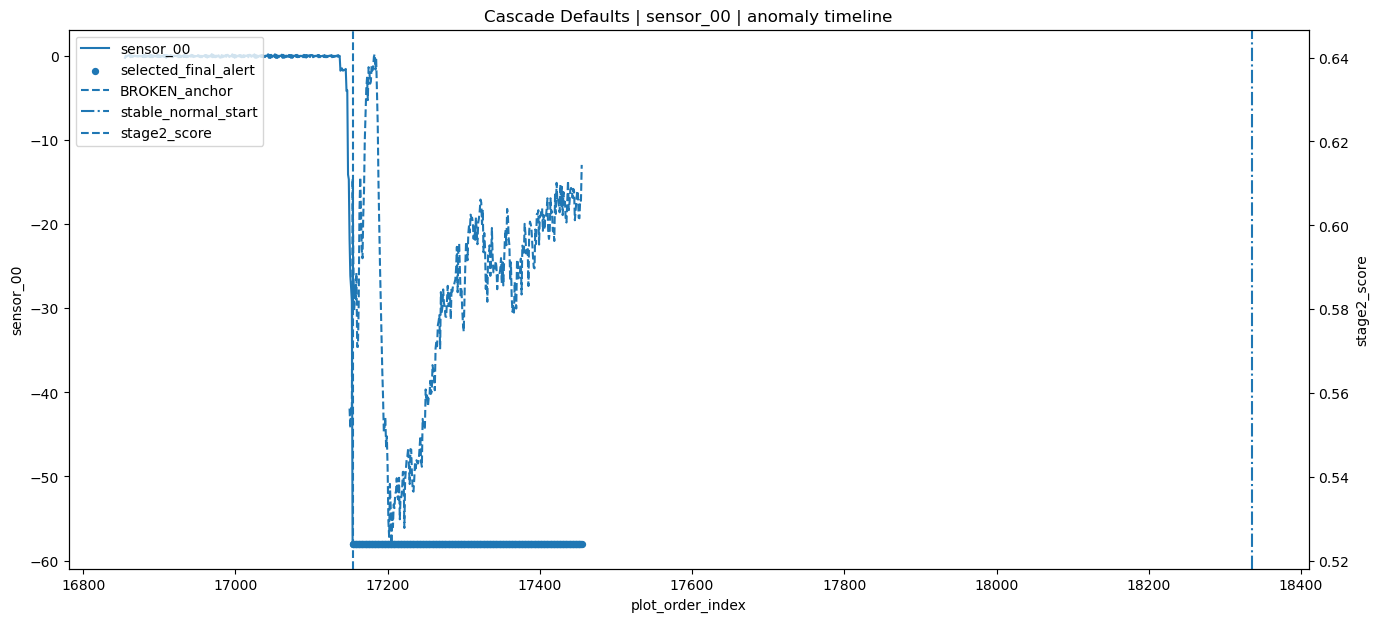

In [81]:
# ============================================================
# Timeline Plot
# ============================================================

def resolve_sensor_column_for_plot(
    dataframe: pd.DataFrame,
    preferred_sensor_column: str = DEFAULT_SENSOR_FOR_TIMELINE,
) -> str:
    if preferred_sensor_column in dataframe.columns:
        return preferred_sensor_column

    sensor_candidates = [c for c in dataframe.columns if c.startswith("sensor_")]
    if not sensor_candidates:
        raise ValueError("No sensor columns found for anomaly timeline plotting.")

    return sensor_candidates[0]


def plot_anomaly_timeline_window(
    dataframe: pd.DataFrame,
    sensor_column: str,
    center_on: str = "broken",   # broken | alert
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (16, 7),
) -> plt.Figure:
    out = dataframe.copy()

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_candidates = out.loc[
        out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    first_alert_plot_order_index = (
        int(alert_candidates.iloc[0]) if not alert_candidates.empty else first_broken_plot_order_index
    )

    center_index = first_alert_plot_order_index if center_on == "alert" else first_broken_plot_order_index

    min_plot_order_index = center_index - rows_before
    max_plot_order_index = center_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        window_df["plot_order_index"],
        window_df[sensor_column],
        label=sensor_column,
    )

    if PRIMARY_SCORE_COLUMN in window_df.columns:
        ax2 = ax1.twinx()
        ax2.plot(
            window_df["plot_order_index"],
            window_df[PRIMARY_SCORE_COLUMN],
            linestyle="--",
            label=PRIMARY_SCORE_COLUMN,
        )
        ax2.set_ylabel(PRIMARY_SCORE_COLUMN)
    else:
        ax2 = None

    alert_df = window_df.loc[window_df[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    if not alert_df.empty:
        ax1.scatter(
            alert_df["plot_order_index"],
            alert_df[sensor_column],
            s=PLOT_ALERT_MARKER_SIZE,
            label="selected_final_alert",
        )

    ax1.axvline(first_broken_plot_order_index, linestyle="--", label="BROKEN_anchor")

    stable_normal_candidates = out.loc[out["episode_phase"].eq("stable_normal"), "plot_order_index"]
    if not stable_normal_candidates.empty:
        stable_normal_start = int(stable_normal_candidates.iloc[0])
        ax1.axvline(stable_normal_start, linestyle="-.", label="stable_normal_start")

    ax1.set_title(f"{PLOT_RUN_LABEL} | {sensor_column} | anomaly timeline")
    ax1.set_xlabel("plot_order_index")
    ax1.set_ylabel(sensor_column)

    handles1, labels1 = ax1.get_legend_handles_labels()
    if ax2 is not None:
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
    else:
        ax1.legend(loc="upper left")

    return fig


sensor_column_for_plot = resolve_sensor_column_for_plot(
    anomaly_timeline_dataframe,
    preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
)

fig = plot_anomaly_timeline_window(
    anomaly_timeline_dataframe,
    sensor_column=sensor_column_for_plot,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

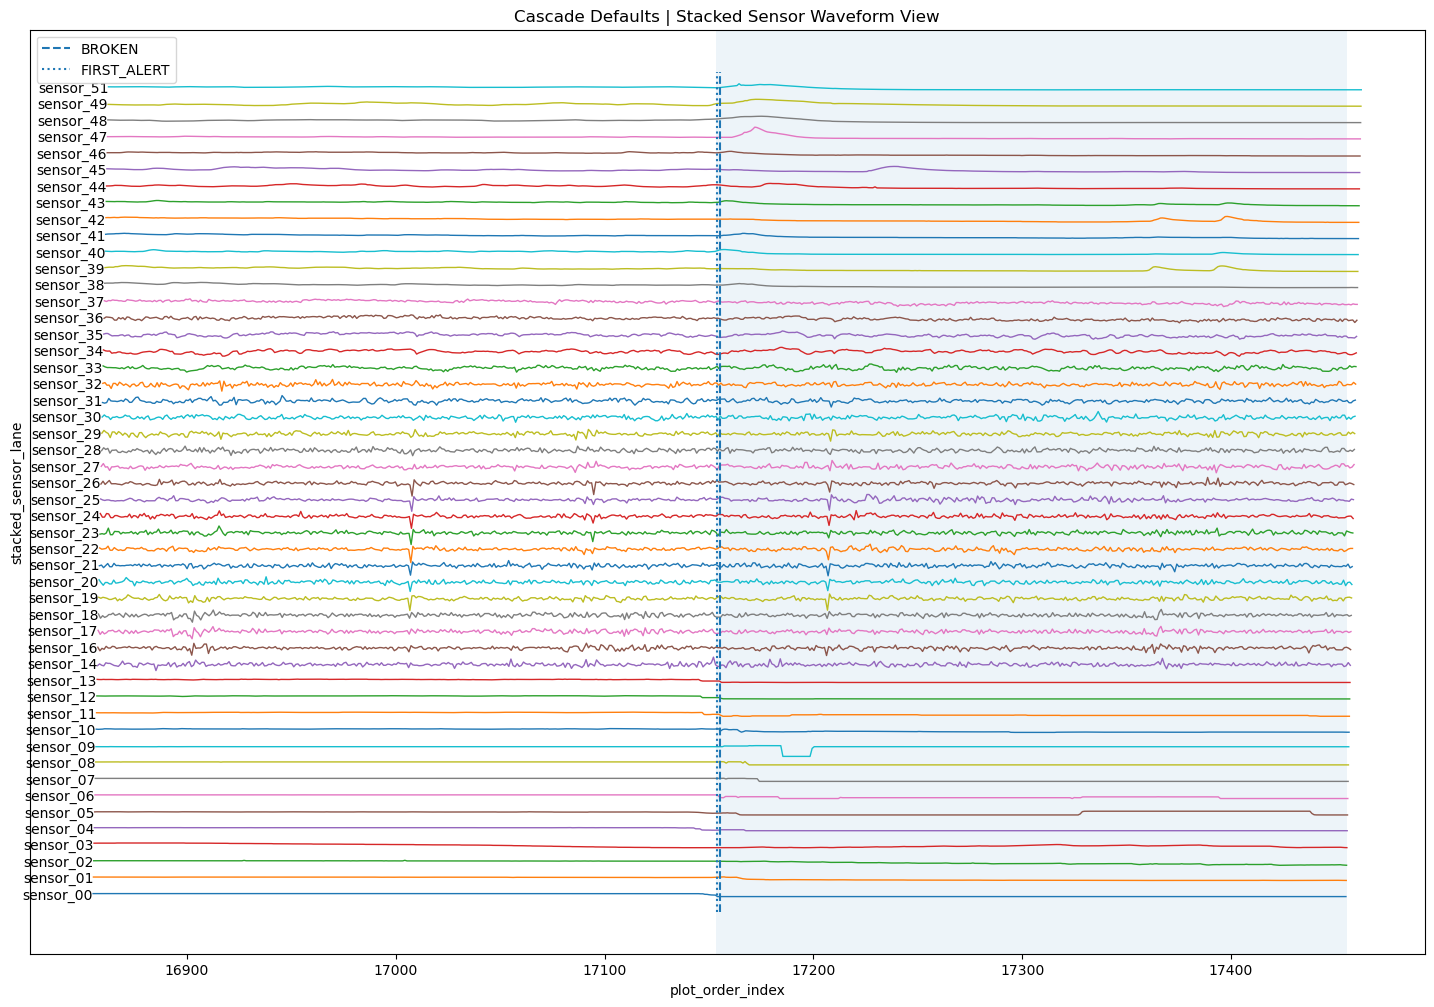

In [82]:
# ============================================================
# Stacked Waveform / Isometric Plot
# ============================================================

def resolve_sensor_columns(
    dataframe: pd.DataFrame,
    sensor_prefix: str = "sensor_",
) -> list[str]:
    sensor_columns = sorted([c for c in dataframe.columns if c.startswith(sensor_prefix)])
    if not sensor_columns:
        raise ValueError("No sensor columns were found in the dataframe.")
    return sensor_columns


def normalize_sensor_columns_for_plot(
    dataframe: pd.DataFrame,
    sensor_columns: list[str],
    method: str = "zscore",
) -> pd.DataFrame:
    out = dataframe.copy()

    for column in sensor_columns:
        series = out[column].astype(float)

        if method == "zscore":
            mean_value = float(series.mean())
            std_value = float(series.std(ddof=0))
            if std_value == 0 or np.isnan(std_value):
                out[column] = 0.0
            else:
                out[column] = (series - mean_value) / std_value
        elif method == "minmax":
            min_value = float(series.min())
            max_value = float(series.max())
            range_value = max_value - min_value
            if range_value == 0 or np.isnan(range_value):
                out[column] = 0.0
            else:
                out[column] = (series - min_value) / range_value
        else:
            raise ValueError(f"Unsupported normalization method: {method}")

    return out


def plot_all_sensors_stacked_waveform(
    dataframe: pd.DataFrame,
    sensor_columns: Optional[list[str]] = None,
    center_on: str = "broken",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    normalize_method: str = "zscore",
    lane_spacing: float = 4.0,
    amplitude_scale: float = 0.9,
    add_isometric_x_shift: bool = True,
    x_shift_per_sensor: float = 0.15,
    figsize: tuple[int, int] = (18, 12),
) -> plt.Figure:
    out = dataframe.copy()

    if sensor_columns is None:
        sensor_columns = resolve_sensor_columns(out)

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_candidates = out.loc[
        out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    first_alert_plot_order_index = (
        int(alert_candidates.iloc[0]) if not alert_candidates.empty else first_broken_plot_order_index
    )

    center_index = first_alert_plot_order_index if center_on == "alert" else first_broken_plot_order_index
    start_index = center_index - rows_before
    end_index = center_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= start_index)
        & (out["plot_order_index"] <= end_index)
    ].copy()

    window_df = normalize_sensor_columns_for_plot(
        window_df,
        sensor_columns=sensor_columns,
        method=normalize_method,
    )

    x_values = window_df["plot_order_index"].to_numpy()

    fig, ax = plt.subplots(figsize=figsize)

    stable_normal_candidates = out.loc[
        out["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    stable_normal_start = int(stable_normal_candidates.iloc[0]) if not stable_normal_candidates.empty else None

    for sensor_idx, sensor_column in enumerate(sensor_columns):
        lane_base = sensor_idx * lane_spacing

        if add_isometric_x_shift:
            x_plot = x_values + (sensor_idx * x_shift_per_sensor)
        else:
            x_plot = x_values

        y_plot = lane_base + (window_df[sensor_column].to_numpy() * amplitude_scale)

        ax.plot(x_plot, y_plot, linewidth=1.0)
        ax.text(x_plot[0], lane_base, sensor_column, va="center", ha="right")

    y_min = -lane_spacing
    y_max = len(sensor_columns) * lane_spacing

    for label, marker_x, style in [
        ("BROKEN", first_broken_plot_order_index, "--"),
        ("FIRST_ALERT", first_alert_plot_order_index, ":"),
    ]:
        if x_values.min() <= marker_x <= x_values.max():
            ax.vlines(marker_x, y_min, y_max, linestyles=style, label=label)

    if stable_normal_start is not None and x_values.min() <= stable_normal_start <= x_values.max():
        ax.vlines(stable_normal_start, y_min, y_max, linestyles="-.", label="STABLE_NORMAL")

    alert_window_df = window_df.loc[
        window_df[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1
    ].copy()

    for _, row in alert_window_df.iterrows():
        marker_x = row["plot_order_index"]
        ax.axvspan(marker_x - 0.5, marker_x + 0.5, alpha=0.08)

    ax.set_title(f"{PLOT_RUN_LABEL} | Stacked Sensor Waveform View")
    ax.set_xlabel("plot_order_index")
    ax.set_ylabel("stacked_sensor_lane")
    ax.set_yticks([])
    ax.legend(loc="upper left")

    return fig


stacked_sensor_columns = resolve_sensor_columns(anomaly_timeline_dataframe)

stacked_waveform_fig = plot_all_sensors_stacked_waveform(
    anomaly_timeline_dataframe,
    sensor_columns=stacked_sensor_columns,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
    normalize_method="zscore",
    lane_spacing=10.0,
    amplitude_scale=0.9,
    add_isometric_x_shift=True,
    x_shift_per_sensor=0.15,
)

plt.show()

In [83]:
# ============================================================
# Baseline vs Cascade Comparison Build
# ============================================================

COMPARISON_RUN_KEY = "cascade_tuned"
# valid:
#   cascade_defaults
#   cascade_tuned
#   stage3_improved

baseline_payload = build_run_timeline_dataframe("baseline")
comparison_payload = build_run_timeline_dataframe(COMPARISON_RUN_KEY)

comparison_summary_df = build_comparison_summary_dataframe(
    [baseline_payload, comparison_payload]
)

ledger.add(
    kind="step",
    step="comparison_build",
    message="Built baseline vs comparison-run timeline payloads and summary dataframe.",
    why="Gold 05 should support direct baseline-vs-cascade timeline review.",
    consequence="Comparison plots and metrics can now be generated on aligned windows.",
    data={
        "comparison_run_key": COMPARISON_RUN_KEY,
        "baseline_row_count": int(len(baseline_payload["timeline_dataframe"])),
        "comparison_row_count": int(len(comparison_payload["timeline_dataframe"])),
    },
    logger=logger,
)

display(comparison_summary_df)

2026-04-21 14:37:01,578 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/pump__gold__baseline_results.pkl
2026-04-21 14:37:35,492 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/pump__gold__cascade_tuned_results.pkl
2026-04-21 14:38:01,907 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:38:01.907305+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'comparison_build', 'message': 'Built baseline vs comparison-run timeline payloads and summary dataframe.', 'why': 'Gold 05 should support direct baseline-vs-cascade timeline review.', 'consequence': 'Comparison plots and metrics can now be generated on aligned windows.', 'data': {'comparison_run_key': 'cascade_tuned', 'baseline_row_count': 220320, 'comparison_row_count': 220320}}


,selected_run_key,plot_run_label,run_family,target_flag_column,primary_score_column,primary_decision_column,row_count,first_alert_plot_order_index,first_broken_plot_order_index,recovery_end_plot_order_index,lead_rows_to_failure,lead_time_seconds_to_failure,total_final_alert_rows,detection_class_counts,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,baseline,Baseline Isolation Forest,baseline,baseline_flag,baseline_score,None,220320,17154,17155,18330,1,1,19493,"{'no_alert': 200827, 'false_positive': 18317, ...",NaN,NaN,NaN,NaN
1,cascade_tuned,Cascade Tuned,cascade,cascade_final_flag,stage2_score,stage2_model_decision,220320,17154,17155,18334,1,1,18479,"{'no_alert': 201841, 'false_positive': 17299, ...",10421.0,17154.0,10421.0,17154.0


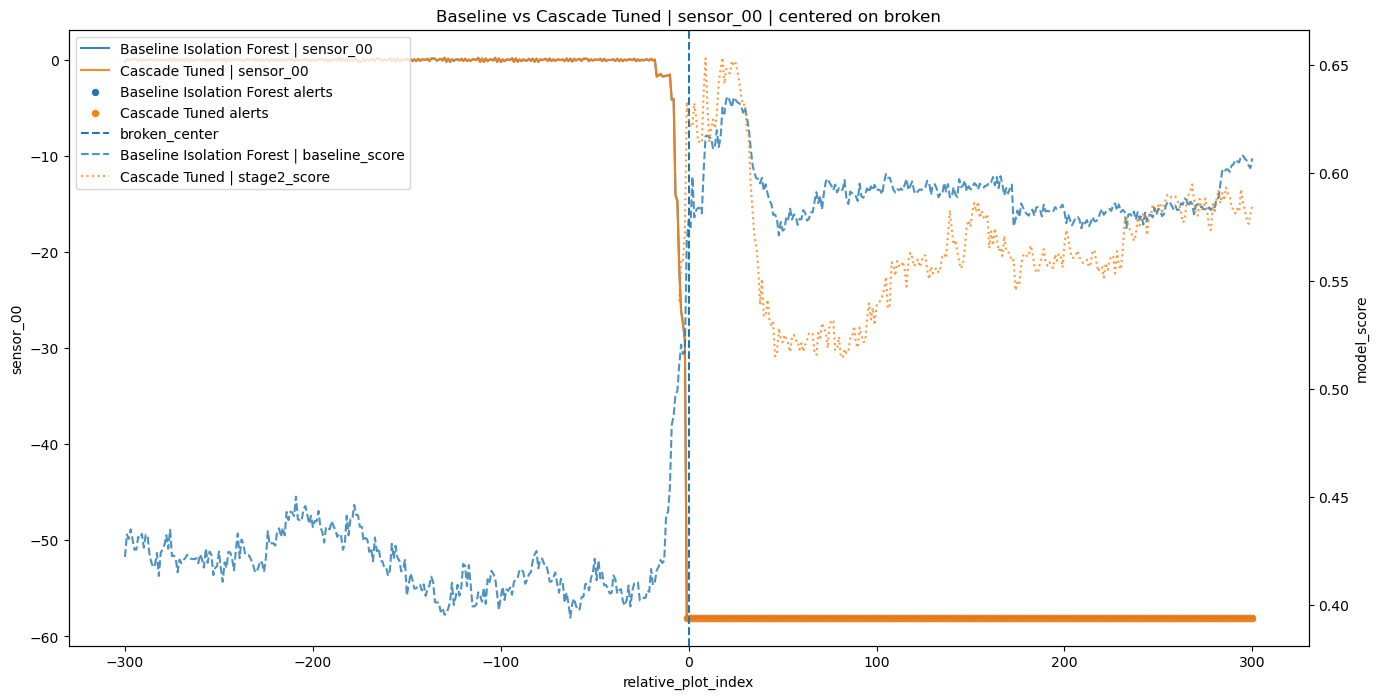

In [84]:
# ============================================================
# Baseline vs Cascade Overlay Plot
# ============================================================

def plot_comparison_overlay(
    baseline_payload: dict[str, Any],
    comparison_payload: dict[str, Any],
    sensor_column: str,
    center_on: str = "broken",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (16, 8),
) -> plt.Figure:
    baseline_df = baseline_payload["timeline_dataframe"].copy()
    comparison_df = comparison_payload["timeline_dataframe"].copy()

    baseline_target_flag_column = baseline_payload["target_flag_column"]
    comparison_target_flag_column = comparison_payload["target_flag_column"]

    baseline_score_column = baseline_payload["primary_score_column"]
    comparison_score_column = comparison_payload["primary_score_column"]

    baseline_center_index = resolve_comparison_center_index(
        baseline_df,
        target_flag_column=baseline_target_flag_column,
        center_on=center_on,
    )
    comparison_center_index = resolve_comparison_center_index(
        comparison_df,
        target_flag_column=comparison_target_flag_column,
        center_on=center_on,
    )

    baseline_window_df = extract_comparison_window(
        baseline_df,
        center_index=baseline_center_index,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    comparison_window_df = extract_comparison_window(
        comparison_df,
        center_index=comparison_center_index,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        baseline_window_df["relative_plot_index"],
        baseline_window_df[sensor_column],
        label=f"{baseline_payload['plot_run_label']} | {sensor_column}",
        alpha=0.9,
    )
    ax1.plot(
        comparison_window_df["relative_plot_index"],
        comparison_window_df[sensor_column],
        label=f"{comparison_payload['plot_run_label']} | {sensor_column}",
        alpha=0.9,
    )

    baseline_alert_df = baseline_window_df.loc[
        baseline_window_df[baseline_target_flag_column].fillna(0).astype(int) == 1
    ].copy()
    if not baseline_alert_df.empty:
        ax1.scatter(
            baseline_alert_df["relative_plot_index"],
            baseline_alert_df[sensor_column],
            s=PLOT_ALERT_MARKER_SIZE,
            label=f"{baseline_payload['plot_run_label']} alerts",
        )

    comparison_alert_df = comparison_window_df.loc[
        comparison_window_df[comparison_target_flag_column].fillna(0).astype(int) == 1
    ].copy()
    if not comparison_alert_df.empty:
        ax1.scatter(
            comparison_alert_df["relative_plot_index"],
            comparison_alert_df[sensor_column],
            s=PLOT_ALERT_MARKER_SIZE,
            label=f"{comparison_payload['plot_run_label']} alerts",
        )

    ax1.axvline(0, linestyle="--", label=f"{center_on}_center")
    ax1.set_xlabel("relative_plot_index")
    ax1.set_ylabel(sensor_column)

    ax2 = ax1.twinx()

    if baseline_score_column is not None and baseline_score_column in baseline_window_df.columns:
        ax2.plot(
            baseline_window_df["relative_plot_index"],
            baseline_window_df[baseline_score_column],
            linestyle="--",
            alpha=0.8,
            label=f"{baseline_payload['plot_run_label']} | {baseline_score_column}",
        )

    if comparison_score_column is not None and comparison_score_column in comparison_window_df.columns:
        ax2.plot(
            comparison_window_df["relative_plot_index"],
            comparison_window_df[comparison_score_column],
            linestyle=":",
            alpha=0.8,
            label=f"{comparison_payload['plot_run_label']} | {comparison_score_column}",
        )

    ax2.set_ylabel("model_score")

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

    ax1.set_title(
        f"Baseline vs {comparison_payload['plot_run_label']} | {sensor_column} | centered on {center_on}"
    )

    return fig


comparison_sensor_column = resolve_sensor_column_for_plot(
    baseline_payload["timeline_dataframe"],
    preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
)

comparison_fig = plot_comparison_overlay(
    baseline_payload=baseline_payload,
    comparison_payload=comparison_payload,
    sensor_column=comparison_sensor_column,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

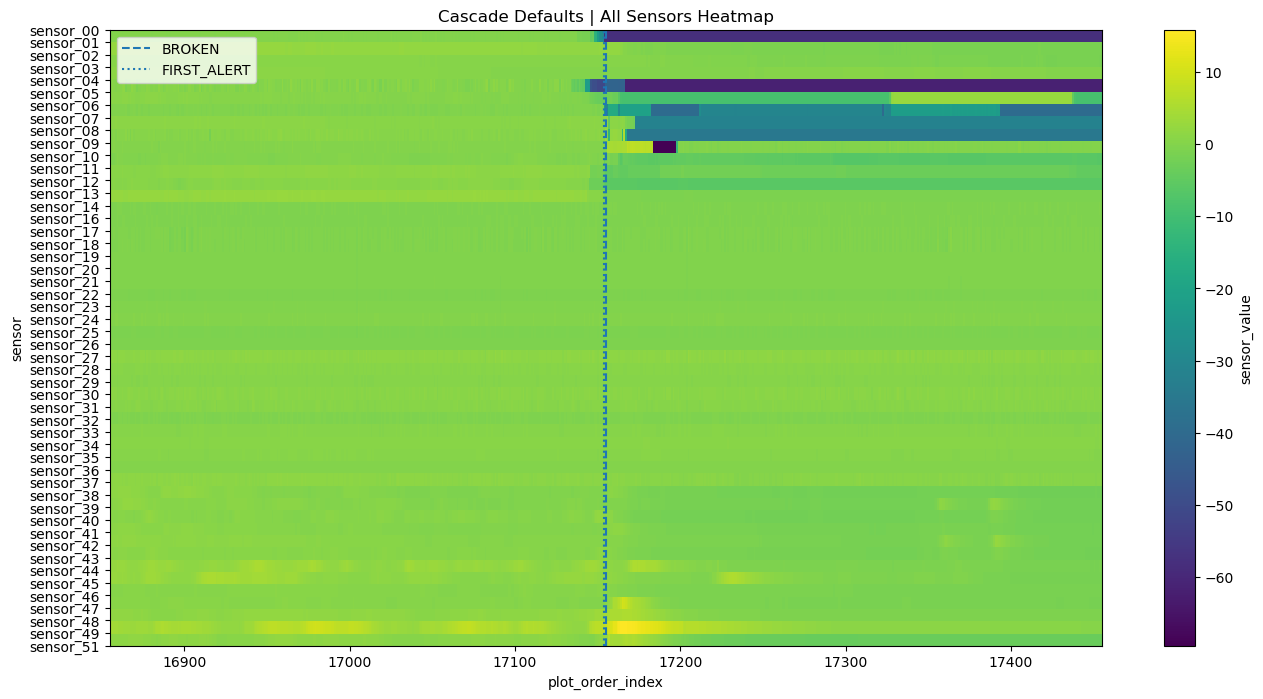

In [85]:
# ============================================================
# All-Sensor Heatmap
# ============================================================

def build_sensor_matrix_for_plot(
    dataframe: pd.DataFrame,
    sensor_columns: list[str],
    time_axis_column: str = "plot_order_index",
    start_index: Optional[int] = None,
    end_index: Optional[int] = None,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    out = dataframe.copy()

    if start_index is not None:
        out = out.loc[out["plot_order_index"] >= start_index].copy()

    if end_index is not None:
        out = out.loc[out["plot_order_index"] <= end_index].copy()

    out = out.sort_values("plot_order_index").reset_index(drop=True)

    if out.empty:
        raise ValueError("Plot window is empty.")

    x_values = out[time_axis_column].to_numpy()
    y_values = np.arange(len(sensor_columns), dtype=np.int64)
    z_matrix = out[sensor_columns].to_numpy().T

    return out, x_values, y_values, z_matrix


def plot_all_sensors_heatmap(
    dataframe: pd.DataFrame,
    sensor_columns: Optional[list[str]] = None,
    center_on: str = "broken",
    time_axis_column: str = "plot_order_index",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (16, 8),
) -> plt.Figure:
    out = dataframe.copy()

    if sensor_columns is None:
        sensor_columns = resolve_sensor_columns(out)

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_candidates = out.loc[
        out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    first_alert_plot_order_index = (
        int(alert_candidates.iloc[0]) if not alert_candidates.empty else first_broken_plot_order_index
    )

    if center_on == "broken":
        center_index = first_broken_plot_order_index
        start_index = center_index - rows_before
        end_index = center_index + rows_after
    elif center_on == "alert":
        center_index = first_alert_plot_order_index
        start_index = center_index - rows_before
        end_index = center_index + rows_after
    else:
        start_index = None
        end_index = None

    window_df, x_values, y_values, z_matrix = build_sensor_matrix_for_plot(
        out,
        sensor_columns=sensor_columns,
        time_axis_column=time_axis_column,
        start_index=start_index,
        end_index=end_index,
    )

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        z_matrix,
        aspect="auto",
        interpolation="nearest",
        extent=[x_values.min(), x_values.max(), len(sensor_columns) - 1, 0],
    )

    ax.set_title(f"{PLOT_RUN_LABEL} | All Sensors Heatmap")
    ax.set_xlabel(time_axis_column)
    ax.set_ylabel("sensor")
    ax.set_yticks(np.arange(len(sensor_columns)))
    ax.set_yticklabels(sensor_columns)

    ax.axvline(first_broken_plot_order_index, linestyle="--", label="BROKEN")

    if x_values.min() <= first_alert_plot_order_index <= x_values.max():
        ax.axvline(first_alert_plot_order_index, linestyle=":", label="FIRST_ALERT")

    stable_normal_candidates = out.loc[
        out["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    if not stable_normal_candidates.empty:
        stable_normal_start = int(stable_normal_candidates.iloc[0])
        if x_values.min() <= stable_normal_start <= x_values.max():
            ax.axvline(stable_normal_start, linestyle="-.", label="STABLE_NORMAL")

    ax.legend(loc="upper left")
    fig.colorbar(im, ax=ax, label="sensor_value")

    return fig


all_sensor_columns = resolve_sensor_columns(anomaly_timeline_dataframe)

all_sensor_heatmap_fig = plot_all_sensors_heatmap(
    anomaly_timeline_dataframe,
    sensor_columns=all_sensor_columns,
    center_on="broken",
    time_axis_column="plot_order_index",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

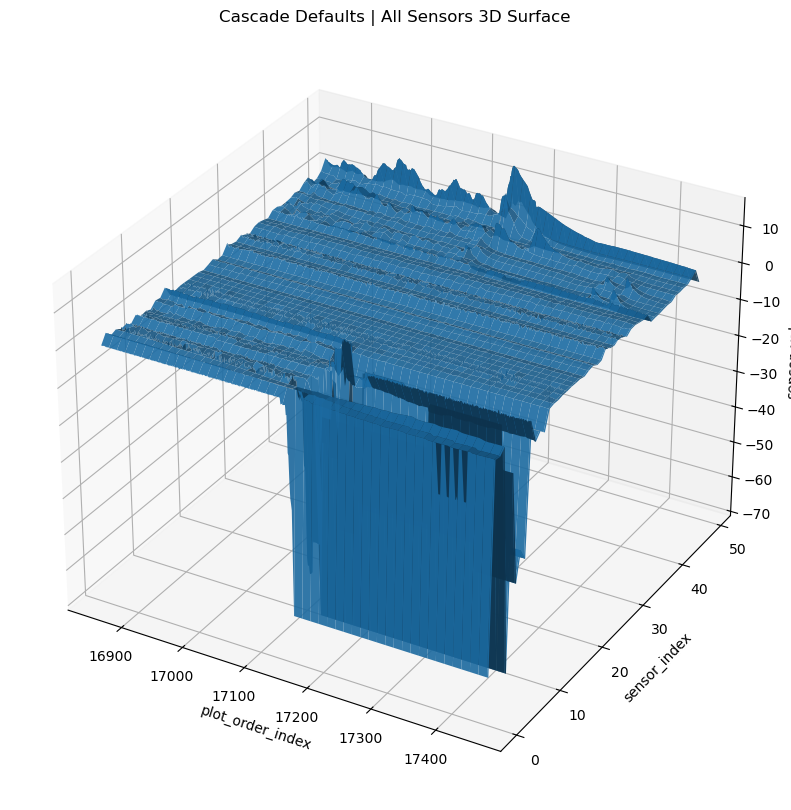

In [86]:
# ============================================================
# All-Sensor 3D Surface
# ============================================================

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_all_sensors_3d_surface(
    dataframe: pd.DataFrame,
    sensor_columns: Optional[list[str]] = None,
    center_on: str = "broken",
    time_axis_column: str = "plot_order_index",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (16, 10),
) -> plt.Figure:
    out = dataframe.copy()

    if sensor_columns is None:
        sensor_columns = resolve_sensor_columns(out)

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_candidates = out.loc[
        out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    first_alert_plot_order_index = (
        int(alert_candidates.iloc[0]) if not alert_candidates.empty else first_broken_plot_order_index
    )

    if center_on == "broken":
        center_index = first_broken_plot_order_index
        start_index = center_index - rows_before
        end_index = center_index + rows_after
    elif center_on == "alert":
        center_index = first_alert_plot_order_index
        start_index = center_index - rows_before
        end_index = center_index + rows_after
    else:
        start_index = None
        end_index = None

    window_df, x_values, y_values, z_matrix = build_sensor_matrix_for_plot(
        out,
        sensor_columns=sensor_columns,
        time_axis_column=time_axis_column,
        start_index=start_index,
        end_index=end_index,
    )

    X, Y = np.meshgrid(x_values, y_values)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X,
        Y,
        z_matrix,
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )

    ax.set_title(f"{PLOT_RUN_LABEL} | All Sensors 3D Surface")
    ax.set_xlabel(time_axis_column)
    ax.set_ylabel("sensor_index")
    ax.set_zlabel("sensor_value")

    return fig


all_sensor_3d_fig = plot_all_sensors_3d_surface(
    anomaly_timeline_dataframe,
    sensor_columns=all_sensor_columns,
    center_on="broken",
    time_axis_column="plot_order_index",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

In [87]:
# ============================================================
# Top-K Alert Packet Review
# ============================================================

TOP_K_ALERT_PACKETS = 5

top_alert_packets_df = (
    alert_packet_summary_df.sort_values(
        by=["contains_pre_failure_alert", "rows_from_packet_start_to_broken", "packet_row_count"],
        ascending=[False, False, False],
    )
    .head(TOP_K_ALERT_PACKETS)
    .reset_index(drop=True)
    if not alert_packet_summary_df.empty
    else pd.DataFrame()
)

ledger.add(
    kind="step",
    step="top_k_alert_packets",
    message="Built top-k alert packet review dataframe.",
    why="Gold 05 should surface the most illustrative alert packets for focused inspection.",
    consequence="Notebook can highlight the strongest early-warning examples.",
    data={"top_k_alert_packets": int(len(top_alert_packets_df))},
    logger=logger,
)

display(top_alert_packets_df)

2026-04-21 14:38:05,666 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:38:05.666060+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'top_k_alert_packets', 'message': 'Built top-k alert packet review dataframe.', 'why': 'Gold 05 should surface the most illustrative alert packets for focused inspection.', 'consequence': 'Notebook can highlight the strongest early-warning examples.', 'data': {'top_k_alert_packets': 5}}


,alert_packet_id,packet_start_plot_order_index,packet_end_plot_order_index,packet_row_count,rows_from_packet_start_to_broken,contains_pre_failure_alert,contains_failure_hit,contains_recovery_alert,contains_stable_normal_alert
0,1,17154,18335,1182,1,1,1,1,0
1,2,18388,18388,1,-1233,0,0,0,1
2,3,18917,19124,204,-1762,0,0,0,1
3,4,24518,27963,3446,-7363,0,0,0,1
4,5,27980,28023,42,-10825,0,0,0,1


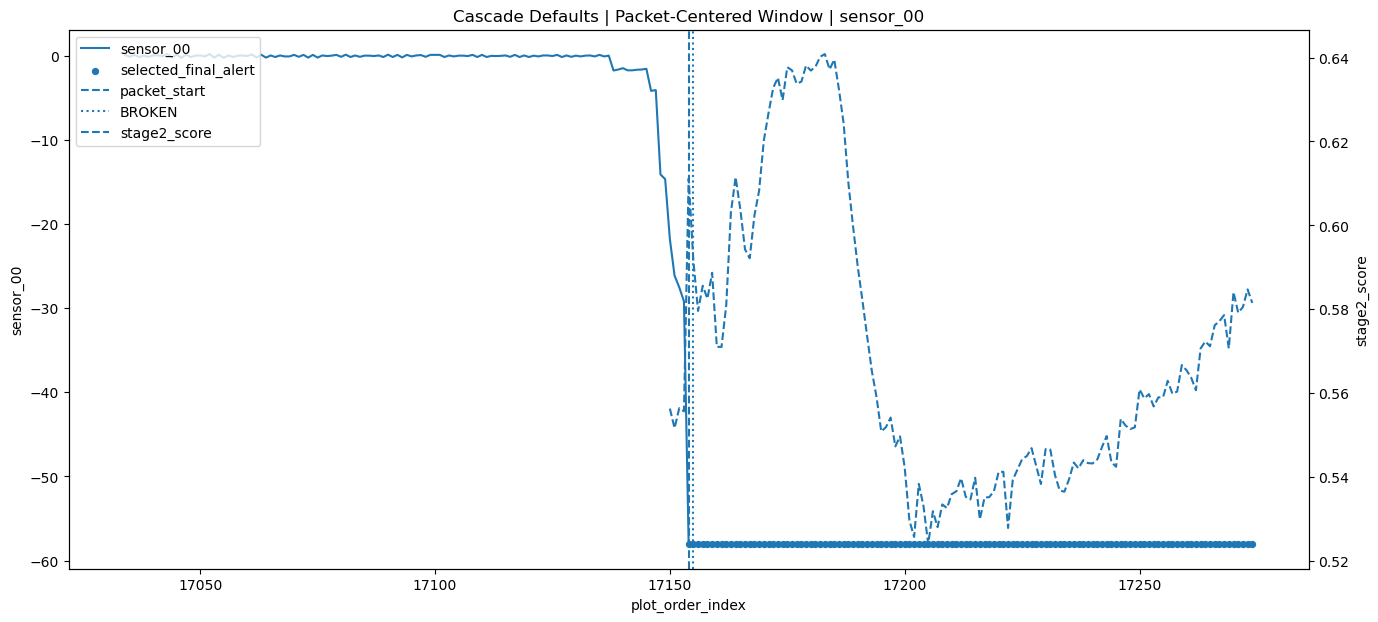

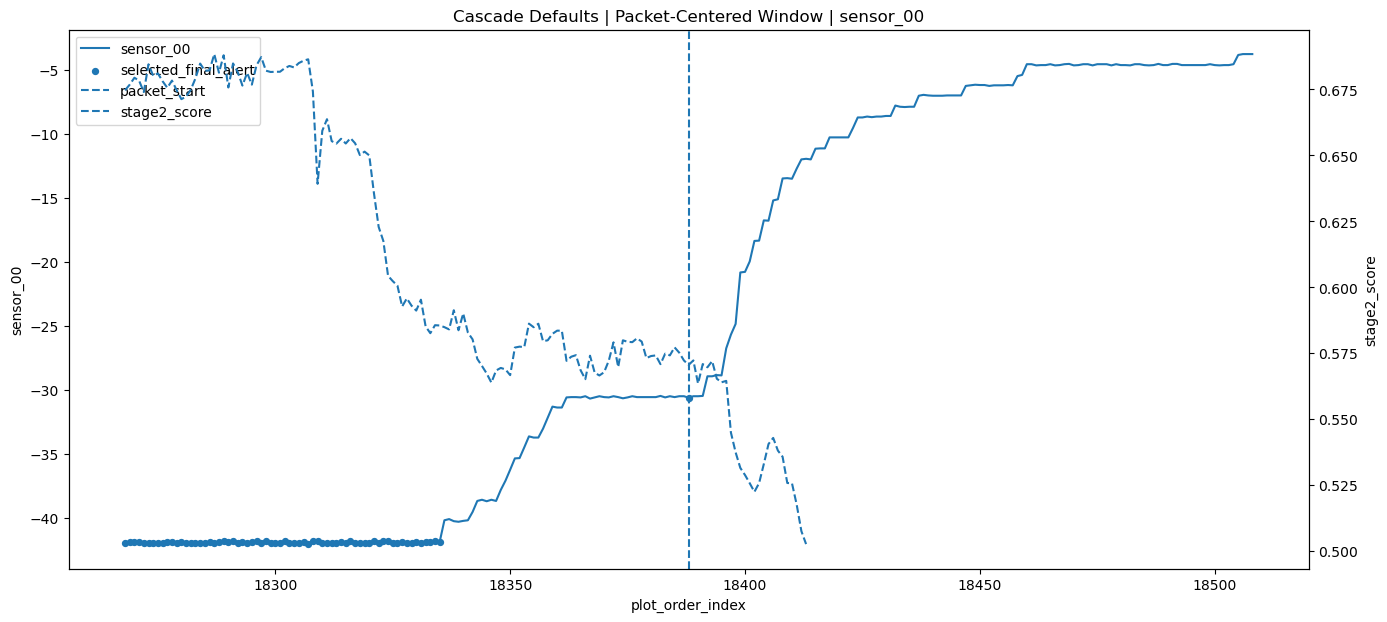

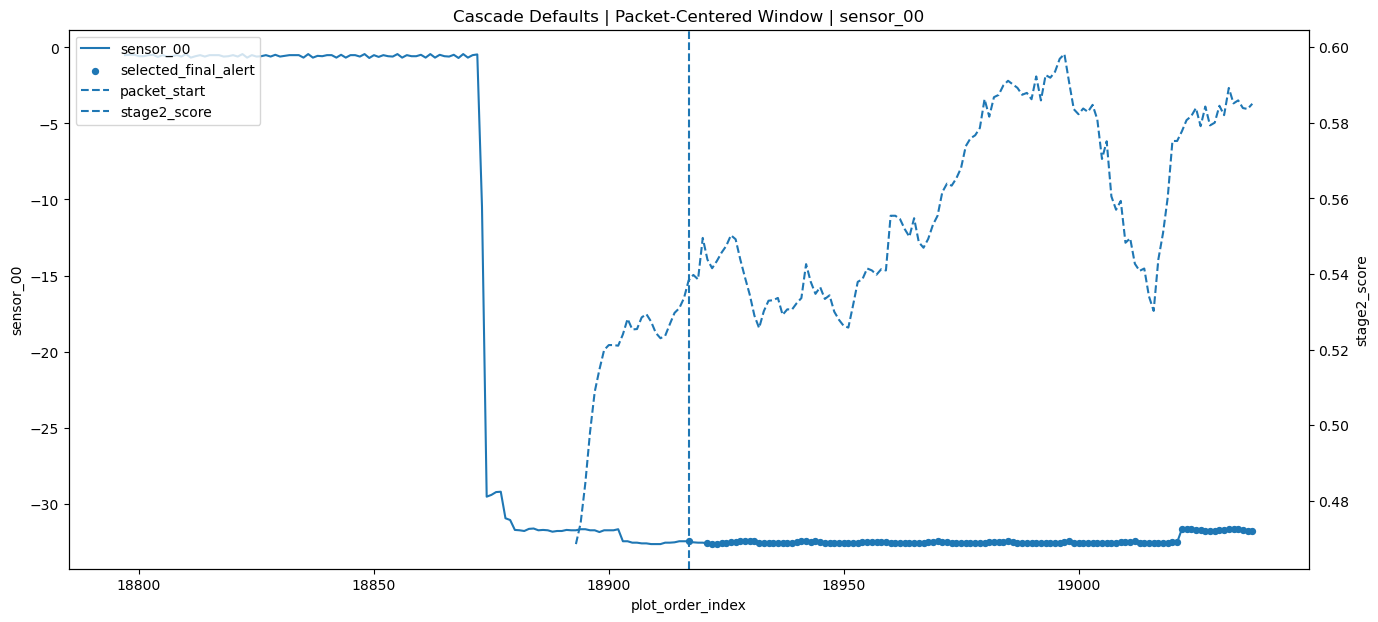

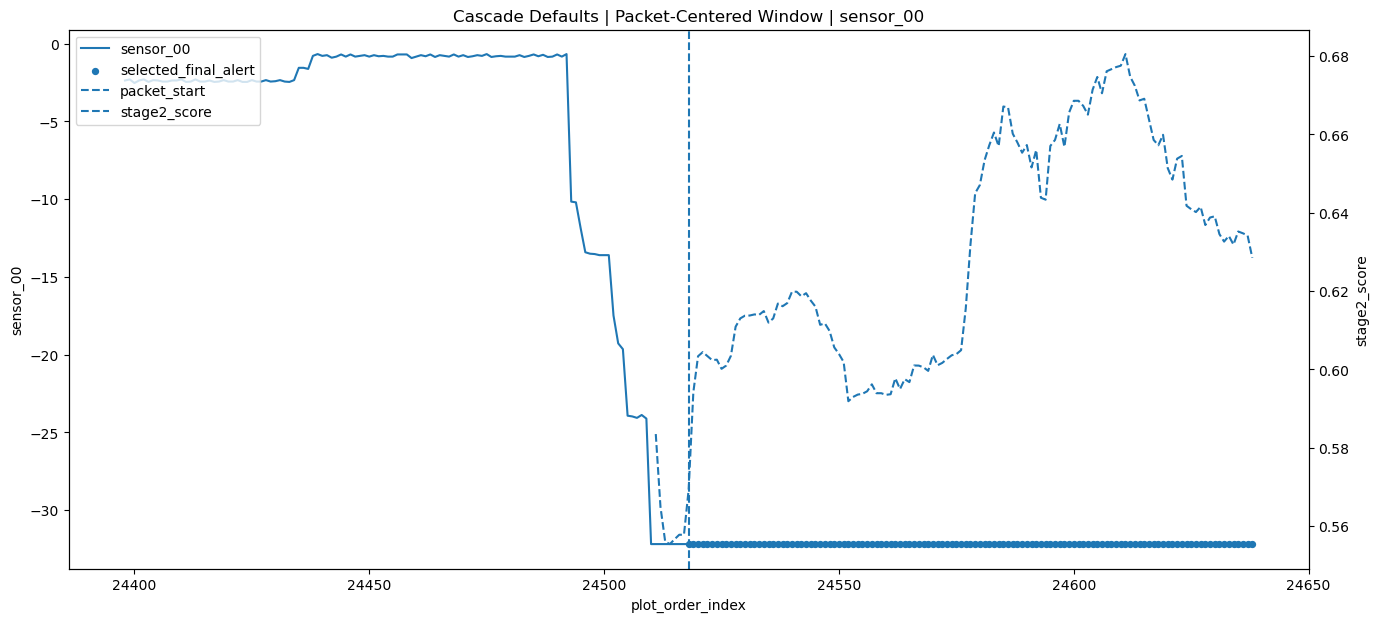

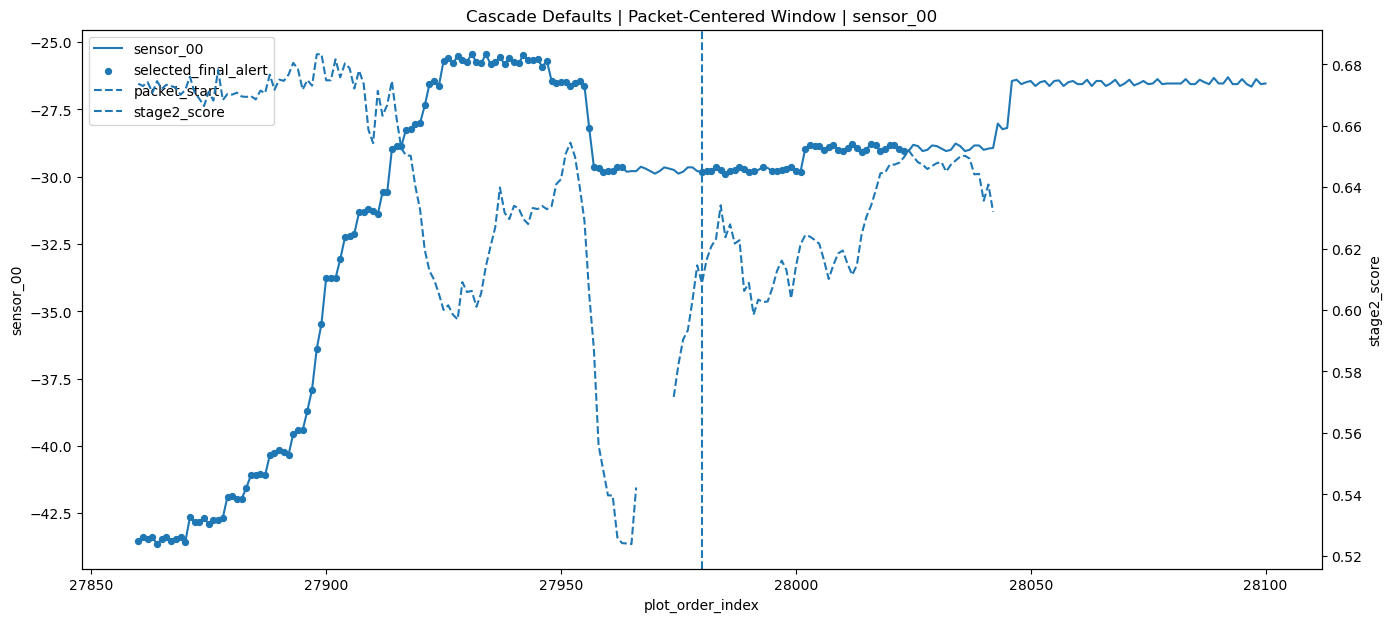

In [88]:
# ============================================================
# Packet-Centered Plot Helper
# ============================================================

def plot_packet_centered_window(
    dataframe: pd.DataFrame,
    packet_start_plot_order_index: int,
    sensor_column: str,
    rows_before: int = 120,
    rows_after: int = 120,
    figsize: tuple[int, int] = (16, 7),
) -> plt.Figure:
    out = dataframe.copy()

    min_plot_order_index = packet_start_plot_order_index - rows_before
    max_plot_order_index = packet_start_plot_order_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        window_df["plot_order_index"],
        window_df[sensor_column],
        label=sensor_column,
    )

    if PRIMARY_SCORE_COLUMN in window_df.columns:
        ax2 = ax1.twinx()
        ax2.plot(
            window_df["plot_order_index"],
            window_df[PRIMARY_SCORE_COLUMN],
            linestyle="--",
            label=PRIMARY_SCORE_COLUMN,
        )
        ax2.set_ylabel(PRIMARY_SCORE_COLUMN)
    else:
        ax2 = None

    alert_df = window_df.loc[window_df[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    if not alert_df.empty:
        ax1.scatter(
            alert_df["plot_order_index"],
            alert_df[sensor_column],
            s=PLOT_ALERT_MARKER_SIZE,
            label="selected_final_alert",
        )

    ax1.axvline(packet_start_plot_order_index, linestyle="--", label="packet_start")

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])
    if min_plot_order_index <= first_broken_plot_order_index <= max_plot_order_index:
        ax1.axvline(first_broken_plot_order_index, linestyle=":", label="BROKEN")

    ax1.set_title(f"{PLOT_RUN_LABEL} | Packet-Centered Window | {sensor_column}")
    ax1.set_xlabel("plot_order_index")
    ax1.set_ylabel(sensor_column)

    handles1, labels1 = ax1.get_legend_handles_labels()
    if ax2 is not None:
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
    else:
        ax1.legend(loc="upper left")

    return fig


packet_figures = []

if not top_alert_packets_df.empty:
    packet_sensor_column = resolve_sensor_column_for_plot(
        anomaly_timeline_dataframe,
        preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
    )

    for _, packet_row in top_alert_packets_df.iterrows():
        packet_start_plot_order_index = int(packet_row["packet_start_plot_order_index"])
        packet_fig = plot_packet_centered_window(
            anomaly_timeline_dataframe,
            packet_start_plot_order_index=packet_start_plot_order_index,
            sensor_column=packet_sensor_column,
            rows_before=120,
            rows_after=120,
        )
        packet_figures.append((packet_start_plot_order_index, packet_fig))
        plt.show()

In [ ]:
# ============================================================
# Export Outputs
# ============================================================

timeline_export_path = ANOMALY_DETECTION_EXPORT_DIR / f"{SELECTED_RUN_KEY}__timeline_export.parquet"
failure_lead_time_export_path = ANOMALY_DETECTION_EXPORT_DIR / f"{SELECTED_RUN_KEY}__failure_lead_time_summary.csv"
alert_packet_export_path = ANOMALY_DETECTION_EXPORT_DIR / f"{SELECTED_RUN_KEY}__alert_packet_summary.csv"
summary_payload_export_path = ANOMALY_DETECTION_EXPORT_DIR / f"{SELECTED_RUN_KEY}__detection_summary.json"
timeline_plot_export_path = ANOMALY_DETECTION_PLOT_DIR / f"{SELECTED_RUN_KEY}__timeline_plot.png"
stacked_waveform_export_path = ANOMALY_DETECTION_PLOT_DIR / f"{SELECTED_RUN_KEY}__stacked_sensor_waveform.png"

timeline_export_df = anomaly_timeline_dataframe.copy()

timeline_export_path = save_data(
    timeline_export_df,
    timeline_export_path.parent,
    timeline_export_path.name,
)

failure_lead_time_export_path = save_data(
    failure_lead_time_df,
    failure_lead_time_export_path.parent,
    failure_lead_time_export_path.name,
)

if not alert_packet_summary_df.empty:
    alert_packet_export_path = save_data(
        alert_packet_summary_df,
        alert_packet_export_path.parent,
        alert_packet_export_path.name,
    )

save_json(
    detection_summary_payload,
    summary_payload_export_path,
)

fig.savefig(timeline_plot_export_path, bbox_inches="tight")
stacked_waveform_fig.savefig(stacked_waveform_export_path, bbox_inches="tight")

ledger.add(
    kind="step",
    step="export_outputs",
    message="Exported Gold 05 timeline outputs and plots.",
    why="Notebook artifacts should be persisted for reporting, dashboarding, and downstream reuse.",
    consequence="Gold 05 artifacts are now available outside the active kernel.",
    data={
        "timeline_export_path": str(timeline_export_path),
        "failure_lead_time_export_path": str(failure_lead_time_export_path),
        "alert_packet_export_path": str(alert_packet_export_path),
        "summary_payload_export_path": str(summary_payload_export_path),
        "timeline_plot_export_path": str(timeline_plot_export_path),
        "stacked_waveform_export_path": str(stacked_waveform_export_path),
    },
    logger=logger,
)

print("Exports written:")
print(f" - {timeline_export_path}")
print(f" - {failure_lead_time_export_path}")
print(f" - {alert_packet_export_path}")
print(f" - {summary_payload_export_path}")
print(f" - {timeline_plot_export_path}")
print(f" - {stacked_waveform_export_path}")

2026-04-21 14:38:14,742 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:38:14.742248+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'export_outputs', 'message': 'Exported Gold 05 timeline outputs and plots.', 'why': 'Notebook artifacts should be persisted for reporting, dashboarding, and downstream reuse.', 'consequence': 'Gold 05 artifacts are now available outside the active kernel.', 'data': {'timeline_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__timeline_export.parquet', 'failure_lead_time_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__failure_lead_time_summary.csv', 'alert_packet_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__alert_packet_summary.csv', 'summary_payload_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_

Exports written:
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__timeline_export.parquet
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__failure_lead_time_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__alert_packet_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__detection_summary.json
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/cascade_defaults__timeline_plot.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/cascade_defaults__stacked_sensor_waveform.png


In [ ]:
# ============================================================
# Additional Exports
# ============================================================

detected_rows_export_path = (
    ANOMALY_DETECTION_EXPORT_DIR
    / f"{SELECTED_RUN_KEY}__detected_rows_review.csv"
)

comparison_summary_export_path = (
    ANOMALY_DETECTION_EXPORT_DIR
    / f"baseline_vs_{COMPARISON_RUN_KEY}__comparison_summary.csv"
)

comparison_plot_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"baseline_vs_{COMPARISON_RUN_KEY}__comparison_plot.png"
)

all_sensor_heatmap_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"{SELECTED_RUN_KEY}__all_sensors_heatmap.png"
)

all_sensor_3d_plot_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"{SELECTED_RUN_KEY}__all_sensors_3d_surface.png"
)

top_alert_packets_export_path = (
    ANOMALY_DETECTION_EXPORT_DIR
    / f"{SELECTED_RUN_KEY}__top_alert_packets.csv"
)

detected_rows_export_path = save_data(
    detected_rows_review_df,
    detected_rows_export_path.parent,
    detected_rows_export_path.name,
)

comparison_summary_export_path = save_data(
    comparison_summary_df,
    comparison_summary_export_path.parent,
    comparison_summary_export_path.name,
)

comparison_fig.savefig(
    comparison_plot_export_path,
    bbox_inches="tight",
)

all_sensor_heatmap_fig.savefig(
    all_sensor_heatmap_export_path,
    bbox_inches="tight",
)

all_sensor_3d_fig.savefig(
    all_sensor_3d_plot_export_path,
    bbox_inches="tight",
)

if not top_alert_packets_df.empty:
    top_alert_packets_export_path = save_data(
        top_alert_packets_df,
        top_alert_packets_export_path.parent,
        top_alert_packets_export_path.name,
    )

    for packet_start_plot_order_index, packet_fig in packet_figures:
        packet_plot_export_path = (
            ANOMALY_DETECTION_PLOT_DIR
            / f"{SELECTED_RUN_KEY}__packet_{packet_start_plot_order_index}__window_plot.png"
        )
        packet_fig.savefig(packet_plot_export_path, bbox_inches="tight")

ledger.add(
    kind="step",
    step="additional_exports",
    message="Exported detected-row review, comparison outputs, heatmap, 3D surface, and packet review artifacts.",
    why="Gold 05 should provide a complete visualization and validation export bundle.",
    consequence="Notebook now writes the full anomaly-review artifact set.",
    data={
        "detected_rows_export_path": str(detected_rows_export_path),
        "comparison_summary_export_path": str(comparison_summary_export_path),
        "comparison_plot_export_path": str(comparison_plot_export_path),
        "all_sensor_heatmap_export_path": str(all_sensor_heatmap_export_path),
        "all_sensor_3d_plot_export_path": str(all_sensor_3d_plot_export_path),
        "top_alert_packets_export_path": str(top_alert_packets_export_path),
    },
    logger=logger,
)

print("Additional exports written:")
print(f" - {detected_rows_export_path}")
print(f" - {comparison_summary_export_path}")
print(f" - {comparison_plot_export_path}")
print(f" - {all_sensor_heatmap_export_path}")
print(f" - {all_sensor_3d_plot_export_path}")
print(f" - {top_alert_packets_export_path}")

2026-04-21 14:38:18,823 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:38:18.823236+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'additional_exports', 'message': 'Exported detected-row review, comparison outputs, heatmap, 3D surface, and packet review artifacts.', 'why': 'Gold 05 should provide a complete visualization and validation export bundle.', 'consequence': 'Notebook now writes the full anomaly-review artifact set.', 'data': {'detected_rows_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__detected_rows_review.csv', 'comparison_summary_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/exports/baseline_vs_cascade_tuned__comparison_summary.csv', 'comparison_plot_export_path': '/workspace/artifacts/gold/pump/anomaly_detection/plots/baseline_vs_cascade_tuned__comparison_plot.png', 'all_sensor_heatmap_export_path': '/works

Additional exports written:
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__detected_rows_review.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/baseline_vs_cascade_tuned__comparison_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/baseline_vs_cascade_tuned__comparison_plot.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/cascade_defaults__all_sensors_heatmap.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/cascade_defaults__all_sensors_3d_surface.png
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/cascade_defaults__top_alert_packets.csv


In [91]:
# ============================================================
# Truth Record for Gold 05
# ============================================================

parent_truth_hash = extract_truth_hash(selected_results)

gold05_truth_base = initialize_layer_truth(
    truth_version=VERSIONS["gold"],
    dataset_name=DATASET_NAME,
    layer_name="gold_anomaly_detection",
    process_run_id=PROCESS_RUN_ID,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=parent_truth_hash,
)

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "config_snapshot",
    {
        "selected_run_key": SELECTED_RUN_KEY,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "primary_score_column": PRIMARY_SCORE_COLUMN,
        "primary_decision_column": PRIMARY_DECISION_COLUMN,
        "recovery_stability_rows": RECOVERY_STABILITY_ROWS,
        "config_hash": loaded_config.config_hash,
        "config_sources": loaded_config.source_files,
    },
)

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "runtime_facts",
    {
        "row_count": int(len(anomaly_timeline_dataframe)),
        "column_count": int(anomaly_timeline_dataframe.shape[1]),
        "first_broken_plot_order_index": recovery_boundary_payload["first_broken_plot_order_index"],
        "recovery_start_plot_order_index": recovery_boundary_payload["recovery_start_plot_order_index"],
        "recovery_end_plot_order_index": recovery_boundary_payload["recovery_end_plot_order_index"],
        "lead_time_seconds_to_failure": detection_summary_payload.get("lead_time_seconds_to_failure"),
        "run_family": RUN_FAMILY,
    },
)

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "artifact_paths",
    {
        "timeline_export_path": str(timeline_export_path),
        "failure_lead_time_export_path": str(failure_lead_time_export_path),
        "alert_packet_export_path": str(alert_packet_export_path),
        "summary_payload_export_path": str(summary_payload_export_path),
        "timeline_plot_export_path": str(timeline_plot_export_path),
        "stacked_waveform_export_path": str(stacked_waveform_export_path),
        "detected_rows_export_path": str(detected_rows_export_path),
        "comparison_summary_export_path": str(comparison_summary_export_path),
        "comparison_plot_export_path": str(comparison_plot_export_path),
        "all_sensor_heatmap_export_path": str(all_sensor_heatmap_export_path),
        "all_sensor_3d_plot_export_path": str(all_sensor_3d_plot_export_path),
        "top_alert_packets_export_path": str(top_alert_packets_export_path),
        "ledger_path": str(GOLD05_LEDGER_PATH),
    },
)

gold05_truth_record = build_truth_record(
    truth_base=gold05_truth_base,
    row_count=len(anomaly_timeline_dataframe),
    column_count=anomaly_timeline_dataframe.shape[1],
    meta_columns=identify_meta_columns(anomaly_timeline_dataframe),
    feature_columns=identify_feature_columns(anomaly_timeline_dataframe),
)

gold05_truth_path = save_truth_record(
    gold05_truth_record,
    truth_dir=paths.truths,
    dataset_name=DATASET_NAME,
    layer_name="gold_anomaly_detection",
)

append_truth_index(
    gold05_truth_record,
    truth_index_path=RESOLVED_PATHS["truth_index_path"],
)

anomaly_timeline_dataframe = stamp_truth_columns(
    anomaly_timeline_dataframe,
    truth_hash=gold05_truth_record["truth_hash"],
    parent_truth_hash=parent_truth_hash,
    pipeline_mode=PIPELINE_MODE,
)

ledger.add(
    kind="step",
    step="truth_record",
    message="Built and saved Gold 05 truth record and stamped the timeline dataframe.",
    why="Gold 05 outputs are derived artifacts and should preserve lineage.",
    consequence="Timeline export now participates in truth-based lineage tracking.",
    data={
        "truth_hash": gold05_truth_record["truth_hash"],
        "truth_path": str(gold05_truth_path),
        "parent_truth_hash": parent_truth_hash,
    },
    logger=logger,
)

display(pd.DataFrame([gold05_truth_record]))

2026-04-21 14:38:19,096 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-04-21T14:38:19.096524+00:00', 'stage': 'gold_anomaly_detection', 'recipe': 'gold05_anomaly_detection__20260421T143546Z', 'kind': 'step', 'step': 'truth_record', 'message': 'Built and saved Gold 05 truth record and stamped the timeline dataframe.', 'why': 'Gold 05 outputs are derived artifacts and should preserve lineage.', 'consequence': 'Timeline export now participates in truth-based lineage tracking.', 'data': {'truth_hash': 'ef6182e79b11e3152d836dd4f865966ea0db018fef4ff3d76c442bd3cafc833f', 'truth_path': '/workspace/artifacts/truths/gold_anomaly_detection/pump__gold_anomaly_detection__truth__ef6182e79b11e3152d836dd4f865966ea0db018fef4ff3d76c442bd3cafc833f.json', 'parent_truth_hash': '12447be32c212ae480ed363d899158bb2e2bf6bde750f61a5a5717a3b22bc42c'}}


,truth_hash,created_at_utc,truth_version,dataset_name,layer_name,process_run_id,pipeline_mode,parent_truth_hash,source_fingerprint,row_count,column_count,meta_columns,feature_columns,config_snapshot,runtime_facts,artifact_paths,notes
0,ef6182e79b11e3152d836dd4f865966ea0db018fef4ff3...,2026-04-21T14:38:18+00:00,gold__001,pump,gold_anomaly_detection,gold05_anomaly_detection__20260421T143546Z,train,12447be32c212ae480ed363d899158bb2e2bf6bde750f6...,{},220320,105,"[meta__asset_id, meta__dataset, meta__episode_...","[anomaly_flag, cascade_final_flag, detection_c...","{'selected_run_key': 'cascade_defaults', 'targ...","{'row_count': 220320, 'column_count': 105, 'fi...",{'timeline_export_path': '/workspace/artifacts...,{}


In [92]:
# ============================================================
# Finalize Ledger
# ============================================================

ledger.write_json(GOLD05_LEDGER_PATH)

logger.info("Gold 05 ledger written to: %s", GOLD05_LEDGER_PATH)
print(f"Ledger written: {GOLD05_LEDGER_PATH}")

2026-04-21 14:38:19,150 | INFO | capstone.gold.anomaly_detection | Gold 05 ledger written to: /workspace/artifacts/gold/pump/anomaly_detection/ledger__pump__gold_anomaly_detection.json


Ledger written: /workspace/artifacts/gold/pump/anomaly_detection/ledger__pump__gold_anomaly_detection.json
